# Bayesian coercivity unmixing with mineralogical priors

Splitting a coercivity spectrum into mineral components is an ill-posed problem: many different combinations of overlapping components can reproduce the same measured curve almost equally well (Heslop, 2015). A single best-fit answer, even one with a near-perfect $R^2$, can hide how poorly some of those components are actually pinned down. The Bayesian methods of `rmag.unmix_coercivity()` (`method='bayes'`) address this by reporting not one decomposition but the full range of decompositions consistent with the data and with what we already know about the likely mineralogy. That range is the posterior, and it lets each component's coercivity and remanence fraction be quoted with an uncertainty. The method also returns the Bayesian evidence, a number that helps decide how many components the data actually support.

The Bayesian methods rely on nested sampling from [`dynesty`](https://dynesty.readthedocs.io), an optional dependency that is not installed with pmagpy. Install it with `pip install dynesty` before running the `method='bayes'` cells below. The other tools in this notebook (the least-squares fit, the bootstrap, and multi-start) do not need it.

This notebook leads with an application and then works through the justification:

1. An application: a constrained Bayesian unmixing of a red-bed hematite mixture.
2. The method: the skew-normal component model, the two data spaces (measurement vs. spectrum), nested sampling, and the three complementary layers of uncertainty (bootstrap, multi-start, posterior).
3. The mineralogical priors: the coercivity-component library with values from the rock-magnetic literature (Egli; Roberts; Özdemir & Dunlop), and how a prior constrains the decomposition without over-determining it.
4. Choosing the number of components: the Bayesian evidence and parsimony.

It builds on the methods introduced in [`coercivity_unmixing.ipynb`](./coercivity_unmixing.ipynb) (data preparation, the component model, and the two fitting spaces).

### A few terms used throughout

This notebook leans on a handful of statistical ideas. Short working definitions:

- **Prior**: what we know about a component before looking at this particular curve, for example the coercivity range a given mineral usually falls in. Priors are optional, and results are shown both with and without them.
- **Posterior**: the set of decompositions consistent with the data and the prior, each with its relative probability. It gives a range of answers rather than a single one.
- **Credible interval**: a Bayesian error bar. A 95% credible interval is the range with a 95% probability of containing the true value, given the model and priors.
- **Evidence** (`logz`): one number summarizing how well a model fits once its flexibility is accounted for. Comparing it between a two- and a three-component fit is one way to decide how many components to use.
- **Ill-posed**: a problem the data alone cannot pin to one answer, so extra information (priors) or careful reporting of the full range is needed.

In [1]:
import pmagpy.rockmag as rmag
import pmagpy.ipmag as ipmag
import pmagpy.contribution_builder as cb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. An application: a red-bed hematite mixture

Red beds carry their remanence in hematite that typically occurs as two populations: a fine, authigenic pigmentary hematite with a broad coercivity distribution, and a coarser, well-crystallized detrital (specular) hematite that is harder and narrower (Roberts, 2025; Özdemir & Dunlop, 2014; Swanson-Hysell et al., 2019). We quantify the two in the backfield curve of red-bed specimen BRIC.20c by unmixing it into two components, each constrained to its mineral's coercivity window with a mineralogical prior from the `rockmagpy` library.

The method rests on two choices, both justified in the sections that follow:

- We fit in spectrum space (`space='spectrum'`): the coercivity spectrum $\mathrm{d}M/\mathrm{d}\log_{10}B$ is fit directly, which reproduces the shape of each coercivity peak and lets the component skewness be set by the data.
- We use a Bayesian fit (`method='bayes'`, nested sampling via `dynesty`): instead of one best-fit decomposition it returns the full posterior, so each component's coercivity and remanence fraction come with a credible interval.

`rmag.mineral_priors` turns the two named mineral components into the prior, and each window constrains that component's mean coercivity directly.

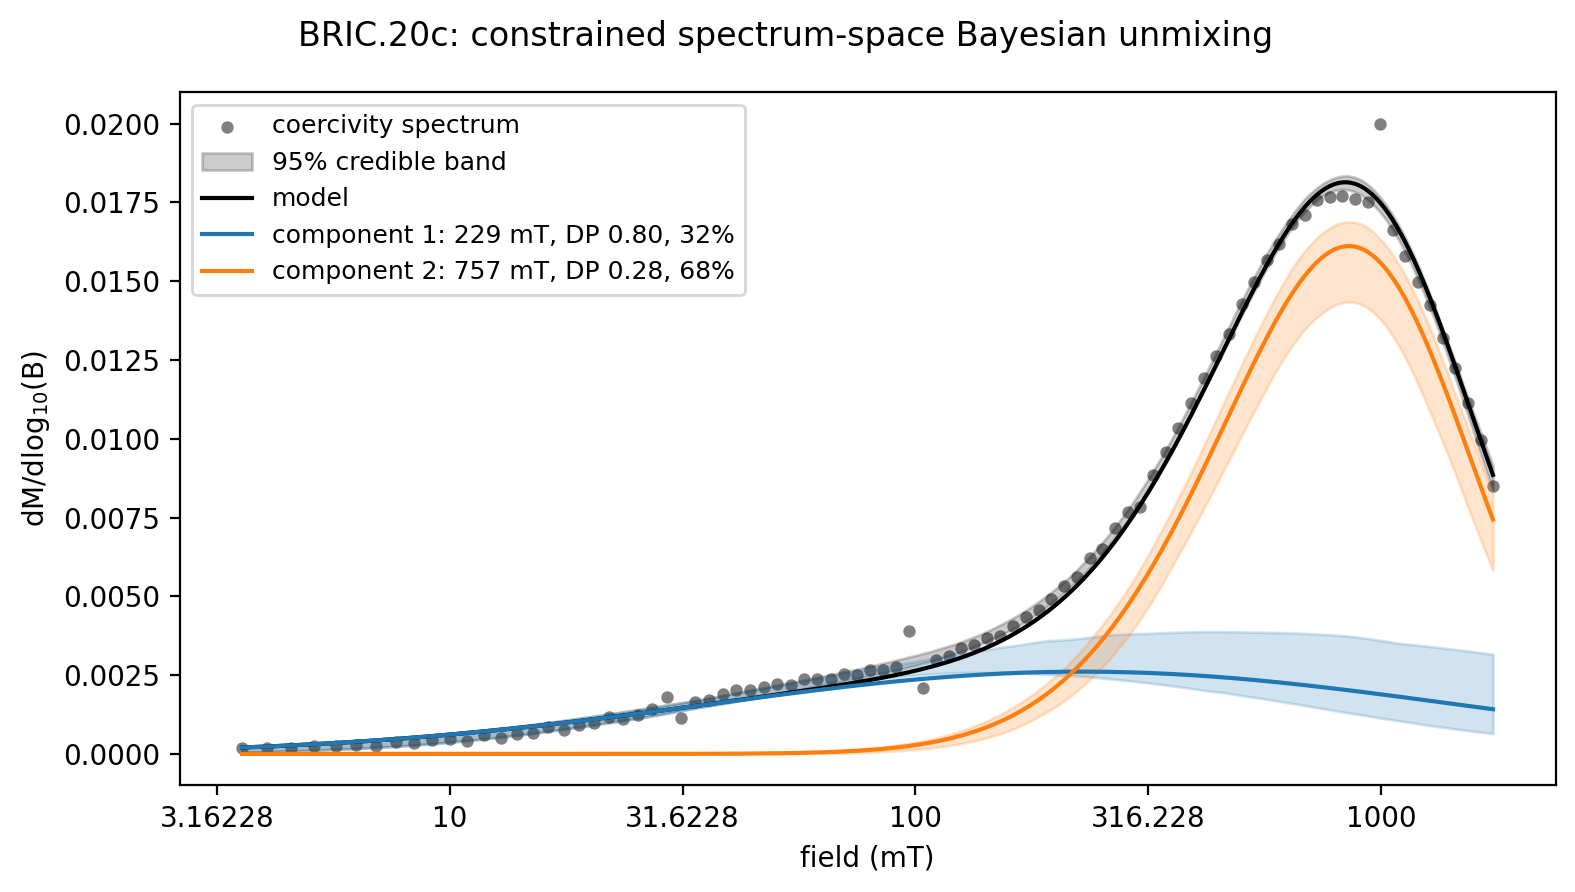

,B_mean_mT_p50,B_mean_mT_p2_5,B_mean_mT_p97_5,proportion_p50,proportion_p2_5,proportion_p97_5
component,,,,,,
1,203.704,152.841,448.673,0.32,0.259,0.452
2,757.301,738.298,792.578,0.68,0.548,0.741


In [2]:
data = pd.read_csv('../example_data/backfield_unmixing/BRIC_20c_backfield.csv')
data.columns = ['B_mT', 'M']
x = np.log10(data['B_mT'].to_numpy())
M = data['M'].to_numpy() - data['M'].min()

# mineralogical priors for the two red-bed hematite populations, with the
# coercivity windows clipped to the measured field range
priors = rmag.mineral_priors(['hematite_pigmentary', 'hematite_detrital'],
                             field_max_mT=10 ** x.max())

# spectrum-space Bayesian unmixing (nested sampling; requires dynesty)
posterior = rmag.unmix_coercivity(x, M, method='bayes', space='spectrum',
                                  priors=priors, vary_skew=True,
                                  nlive=250, random_seed=1)

fig, axes = rmag.plot_coercivity_unmixing(
    posterior, title='BRIC.20c: constrained spectrum-space Bayesian unmixing')
plt.show()
posterior['bayes']['param_summary'][
    ['B_mean_mT_p50', 'B_mean_mT_p2_5', 'B_mean_mT_p97_5',
     'proportion_p50', 'proportion_p2_5', 'proportion_p97_5']].round(3)

The fit resolves the two hematite populations and reports how well each is constrained. The detrital component is pinned tightly (mean coercivity ~760 mT, a narrow credible interval), while the broad pigmentary component is far less certain (mean ~200 mT, but a wide interval reaching several hundred mT). The posterior reports exactly this range, which a single best-fit would not reveal. Because each component is confined to its mineral's window, the second component's posterior proportion can be read as the detrital-hematite fraction of the remanence, with a credible interval (~0.68 [0.55, 0.74]). The `param_summary` table carries these percentiles for every parameter and derived quantity, including the median and peak coercivities (`B_median_mT`, `B_peak_mT`).

## 2. The method

The application above rests on three decisions: fit the spectrum, fit it with a Bayesian approach, and constrain it with mineral priors. Each addresses a specific weakness of a plain best-fit unmixing, and this section builds up the pieces in turn.

### A reference least-squares fit, and why its $R^2$ is not enough

We start from an ordinary best-fit decomposition of the same BRIC.20c curve: two symmetric components fit by least squares in measurement space (the approach of [`coercivity_unmixing.ipynb`](./coercivity_unmixing.ipynb)). It has an excellent $R^2$, and yet, as the uncertainty layers below show, its broad component is not as well constrained as that would suggest. A high $R^2$ measures goodness of fit, not how uniquely the components are determined.

R^2 = 0.99998


,B_mean_mT,sd_log,proportion
component,,,
1,248.333,0.694,0.357
2,836.779,0.285,0.643


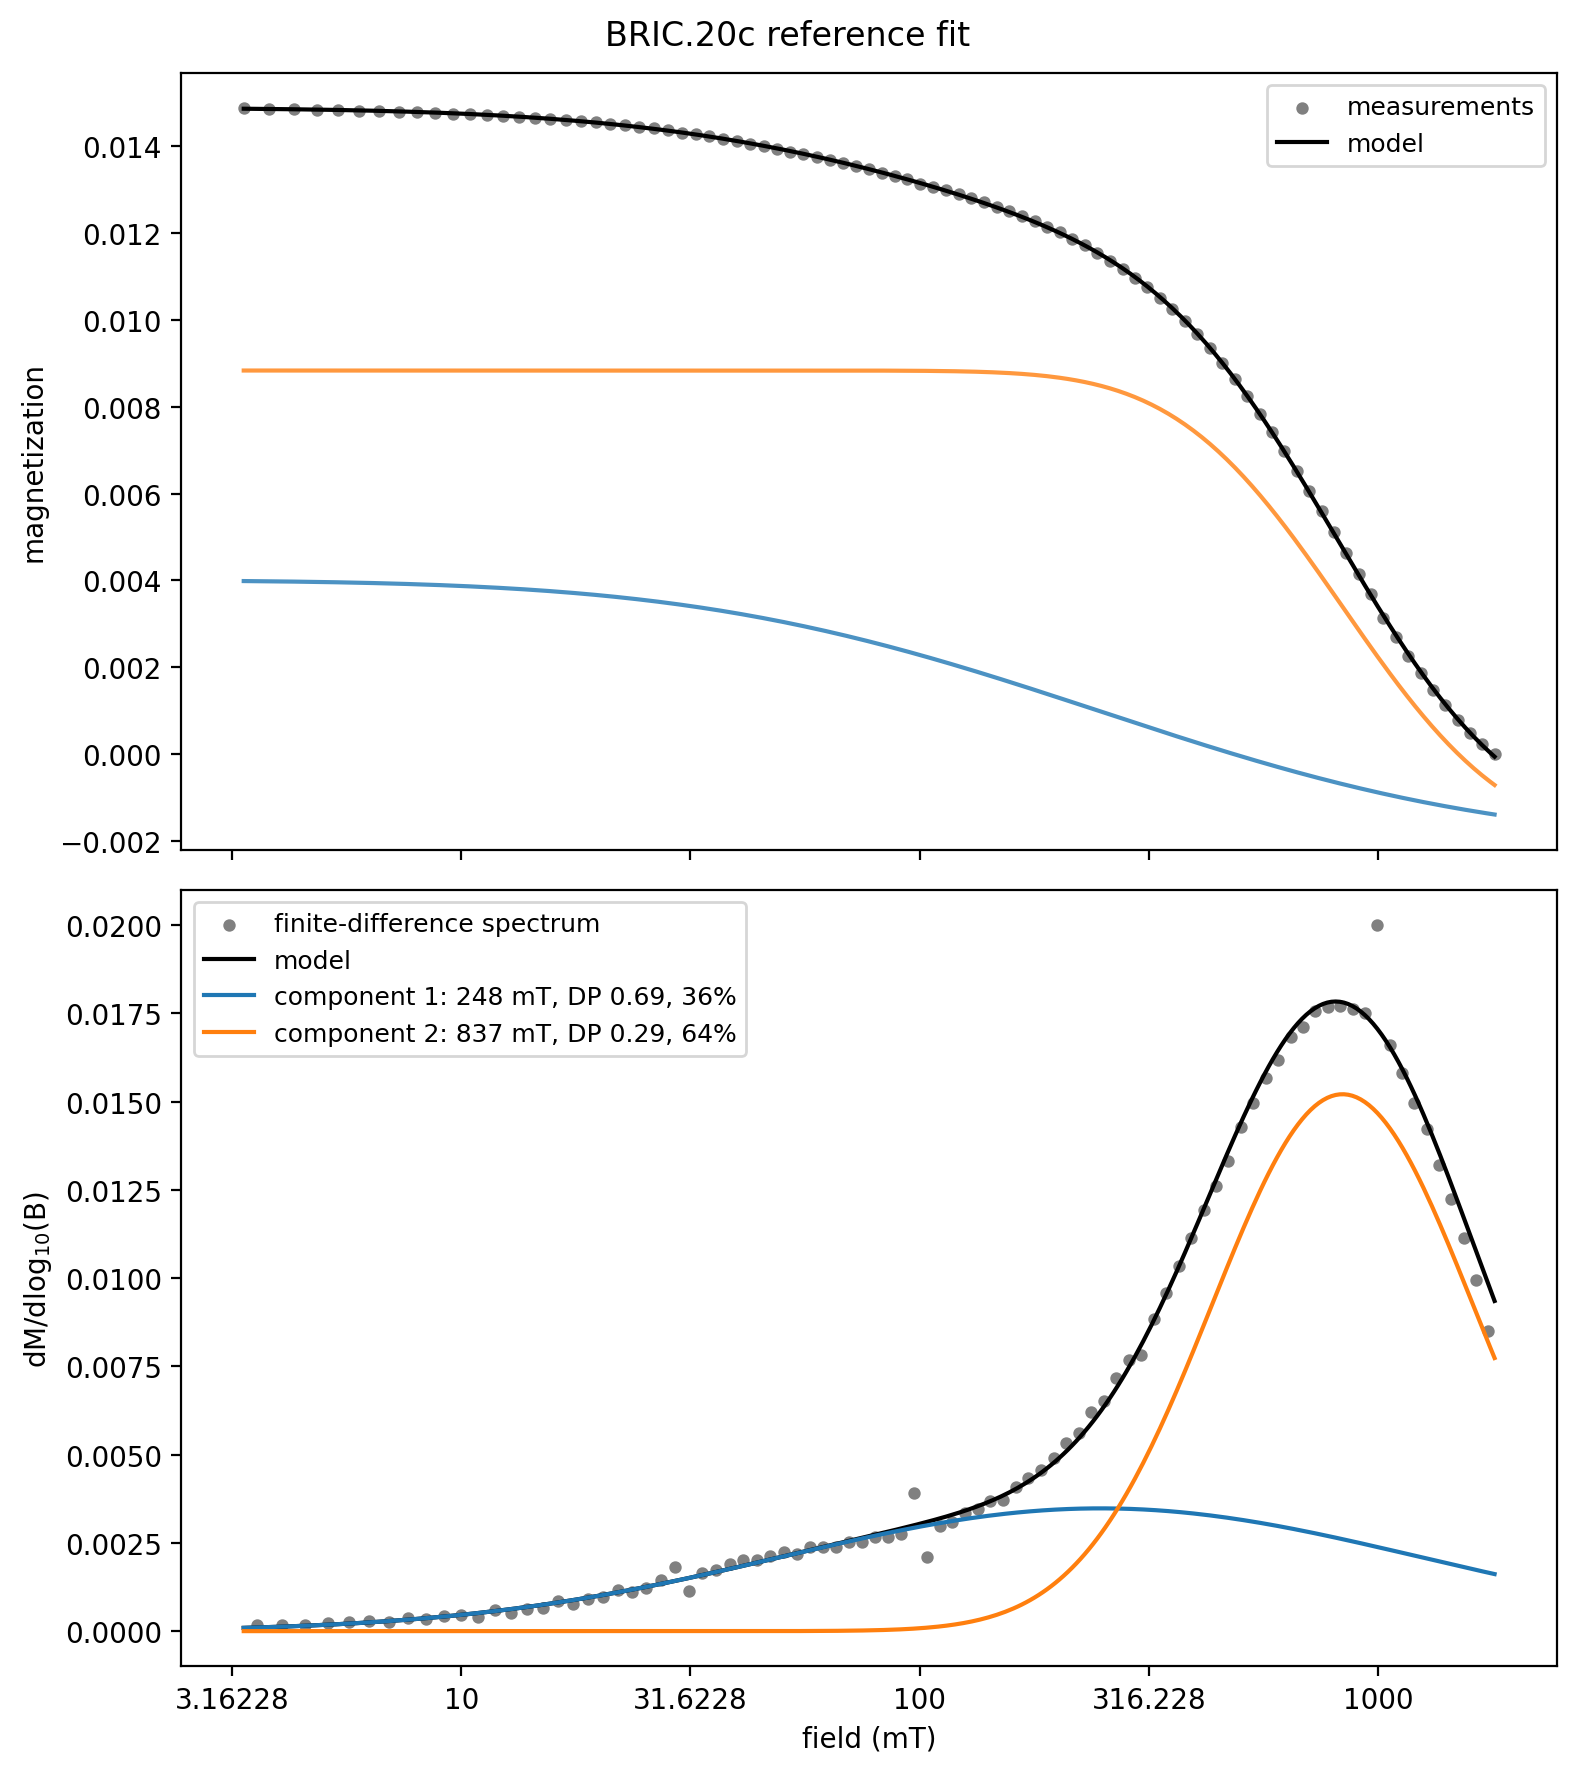

In [3]:
data = pd.read_csv('../example_data/backfield_unmixing/BRIC_20c_backfield.csv')
data.columns = ['B_mT', 'M']
x = np.log10(data['B_mT'].to_numpy())
M = data['M'].to_numpy() - data['M'].min()

reference = rmag.unmix_coercivity(x, M, method='curve', n_components=2,
                                  vary_skew=False)
fig, axes = rmag.plot_coercivity_unmixing(reference, title='BRIC.20c reference fit')
print(f"R^2 = {reference['stats']['r_squared']:.5f}")
reference['params'][['B_mean_mT', 'sd_log', 'proportion']].round(3)

The fit looks excellent ($R^2 > 0.999$). Taken at face value it says the spectrum is a 240 mT component carrying ~36% of the remanence and an 830 mT component carrying ~64%. The rest of this notebook asks how much we should trust those numbers.

## Layer 1: noise repeatability with the bootstrap

The bootstrap resamples the data many times and refits, starting each replicate from the best-fit parameters. The spread of the refits measures how sensitive the solution is to measurement noise. `rockmagpy` propagates this into percentile intervals on every parameter and derived quantity.

In [4]:
reference_boot = rmag.unmixing_bootstrap(reference, n_boot=500, random_seed=1)
reference_boot['bootstrap']['param_summary'][[
    'B_mean_mT_p2_5', 'B_mean_mT_p50', 'B_mean_mT_p97_5',
    'proportion_p2_5', 'proportion_p50', 'proportion_p97_5']].round(3)

,B_mean_mT_p2_5,B_mean_mT_p50,B_mean_mT_p97_5,proportion_p2_5,proportion_p50,proportion_p97_5
component,,,,,,
1,196.821,242.878,284.059,0.307,0.353,0.386
2,827.025,837.445,857.173,0.614,0.647,0.693


### Visualizing the bootstrap uncertainty

Three views make the uncertainty concrete. The marginal distributions show how tightly each parameter is pinned down; the ensemble plot overlays many resampled decompositions so the spread is visible directly in spectrum space; and the trade-off plot exposes correlations between parameters that the marginal intervals hide.

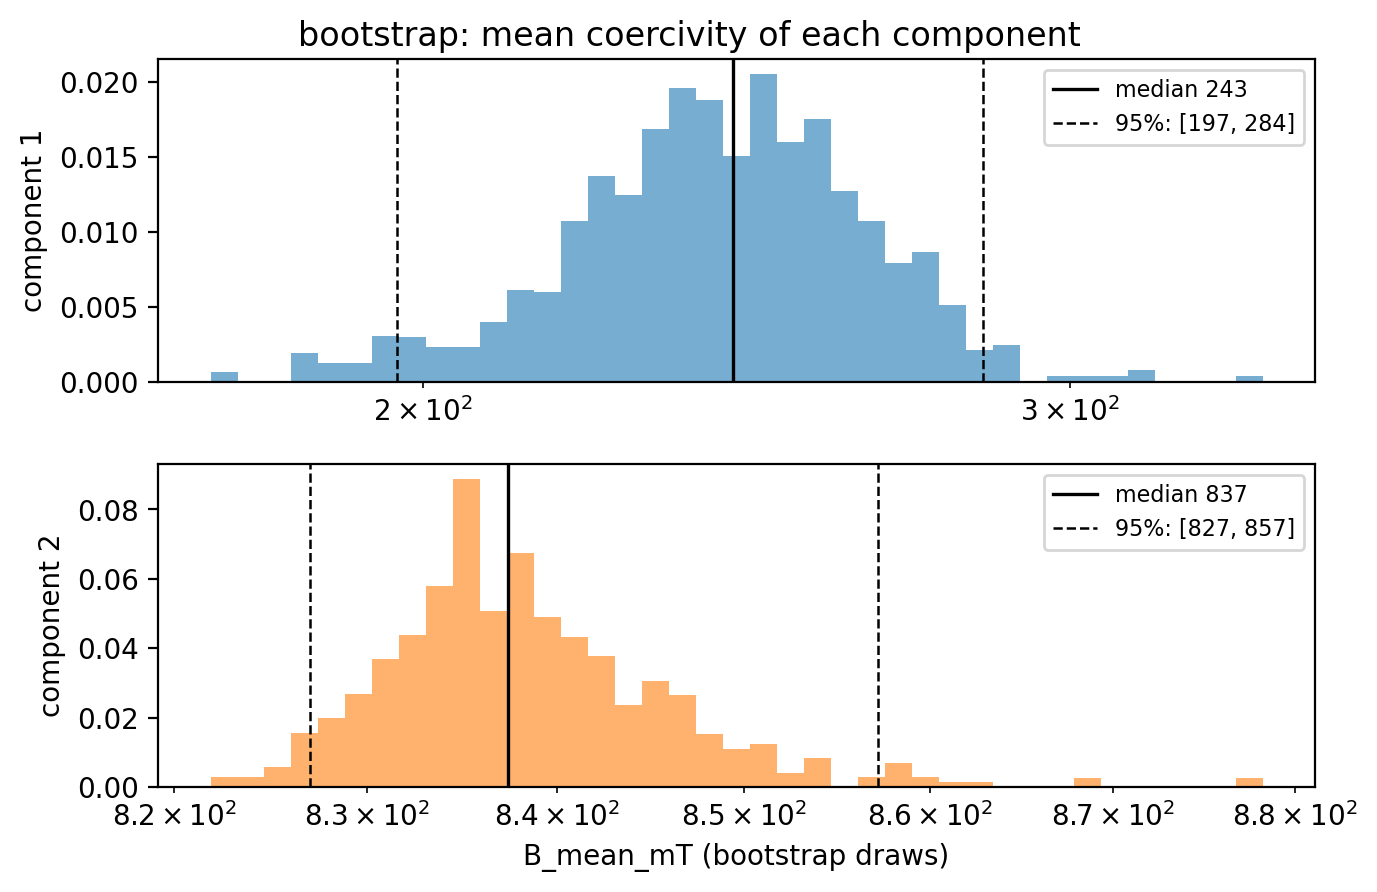

In [5]:
fig, axes = rmag.plot_unmixing_posterior(reference_boot, quantity='B_mean_mT')
fig.suptitle('bootstrap: mean coercivity of each component', y=1.01)
plt.show()

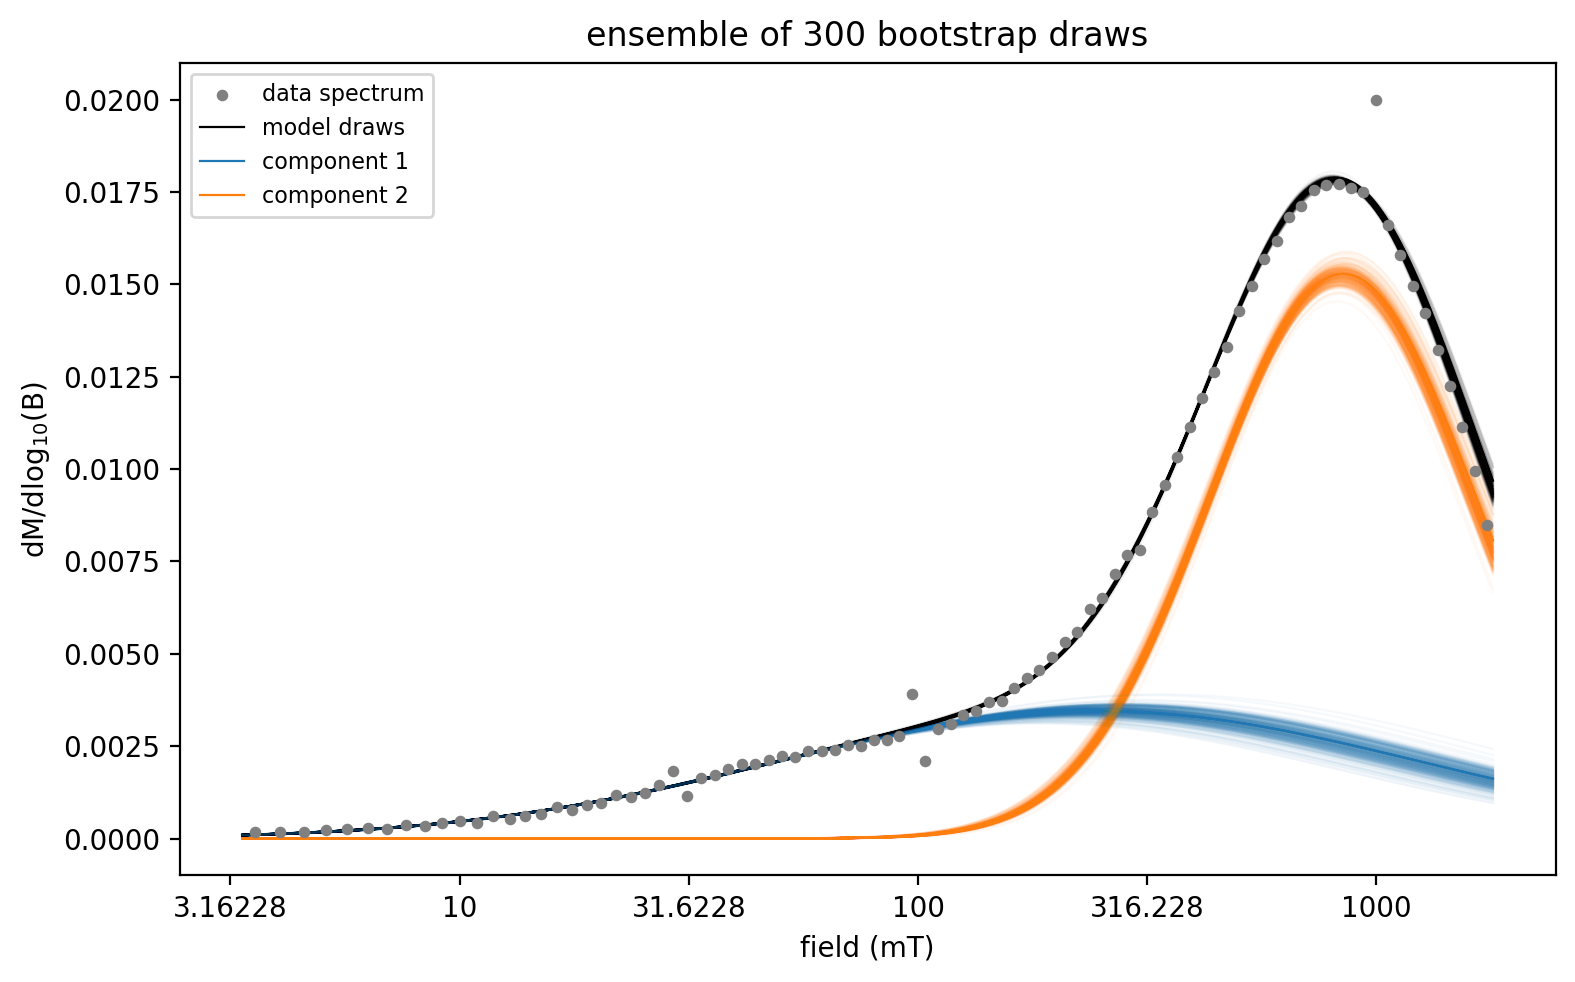

In [6]:
fig, ax = rmag.plot_unmixing_ensemble(reference_boot, space='spectrum',
                                      n_draws=300, random_seed=1)
plt.show()

The ensemble plot already tells the key story: the high-coercivity component (component 2) is drawn as a tight bundle and is well constrained, while the low-coercivity component (component 1) fans out widely, because a broad component overlapping a narrow one is inherently harder to pin down. A single error bar on "component 1 = 240 mT" would not have conveyed this.

The trade-off plot shows why the broad component is uncertain: its coercivity and its proportion are correlated, so the data constrain a ridge of $(B, \text{proportion})$ combinations rather than a single point.

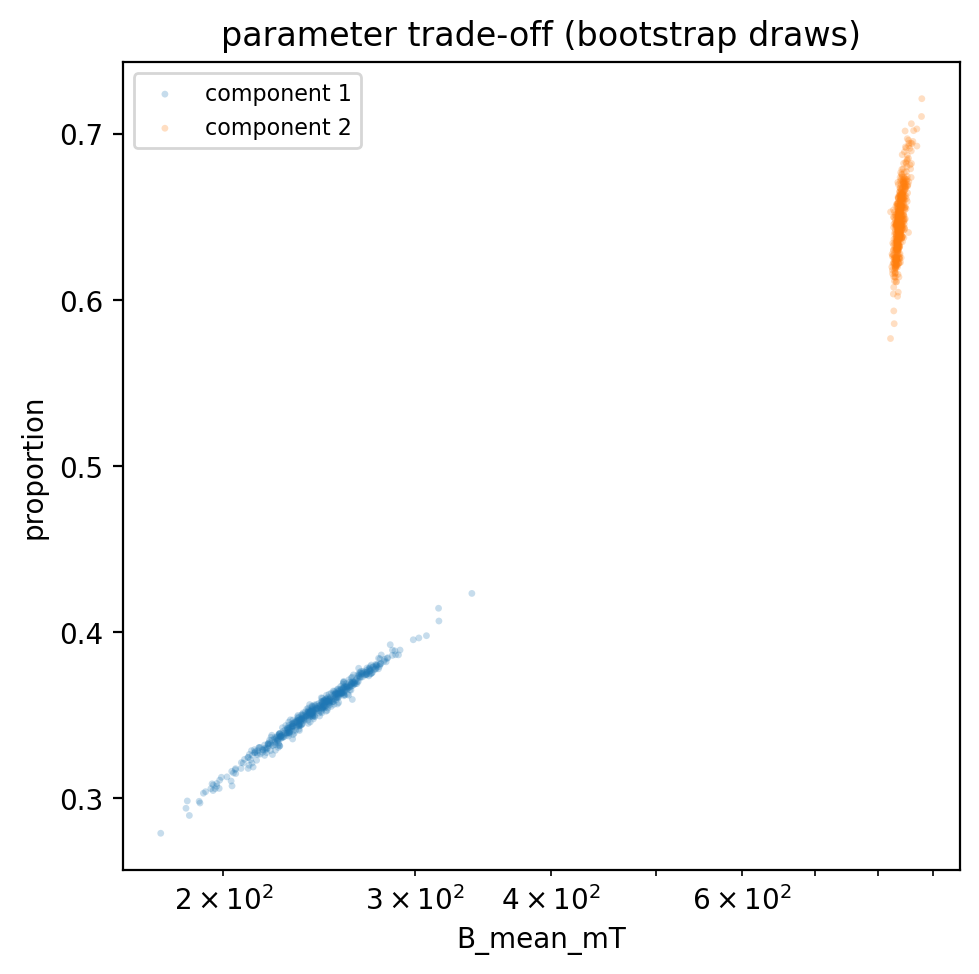

In [7]:
fig, ax = rmag.plot_unmixing_tradeoff(reference_boot, x='B_mean_mT',
                                      y='proportion')
plt.show()

### The limitation of the bootstrap

The bootstrap restarts every replicate from the best-fit parameters, so it can only explore the neighborhood of one solution: the basin the optimizer happened to land in. If the spectrum admits a genuinely different decomposition, the bootstrap will not find it, and its tight-looking intervals will give false confidence. That is what the next layer addresses.

## Layer 2: solution non-uniqueness with multi-start fitting

The deeper problem in coercivity unmixing is that a spectrum can often be reproduced by genuinely different combinations of components: different local minima of the fit, each an internally consistent decomposition. A single optimization lands in whichever basin its starting guess happens to fall into, and reports that one solution as if it were unique.

`unmixing_multistart` confronts this. It launches the fit from many dispersed random initializations, lets each converge, and then clusters the results into distinct solutions. Two fits count as the same solution when every component's coercivity agrees within about 0.1 log₁₀ unit and every remanence proportion within 0.05 (set by `location_tolerance` and `proportion_tolerance`). For each distinct solution it reports the fit statistics (RSS, ΔAIC, and an Akaike weight) and the number of random starts that reached it (`n_hits`). We let skew vary here, which enlarges the solution space and makes the non-uniqueness vivid. (To keep many-start searches fast, `unmixing_multistart`, like `select_n_components`, runs its trial fits without resampling, passing `n_boot=0` for resampling methods, and applies the full resampling uncertainty only to the winning fit.)

In [8]:
multistart = rmag.unmixing_multistart(x, M, method='curve', n_components=2,
                                      n_starts=80, vary_skew=True,
                                      random_seed=7, verbose=True)
solutions = multistart['multistart']['solutions']
solutions[['n_hits', 'r_squared', 'delta_aic',
           'B_mean_mT_c1', 'proportion_c1',
           'B_mean_mT_c2', 'proportion_c2']].round(3)

81/81 fits converged; 5 distinct solution(s)


,n_hits,r_squared,delta_aic,B_mean_mT_c1,proportion_c1,B_mean_mT_c2,proportion_c2
solution,,,,,,,
1,4,1.0,0.000,51.904,0.132,674.975,0.868
2,9,1.0,23.175,102.110,0.207,738.004,0.793
3,10,1.0,67.598,105.499,0.261,843.877,0.739
4,1,1.0,116.303,229.717,0.422,1033.147,0.578
5,57,1.0,128.765,248.321,0.357,836.780,0.643


The table already shows the problem numerically, but it becomes far clearer visually. `rmag.plot_unmixing_multistart` draws each distinct solution's decomposition against the data as a small multiple, and adds a solution map that places every solution's components on a coercivity-versus-proportion plot (marker size scaled by Akaike weight).

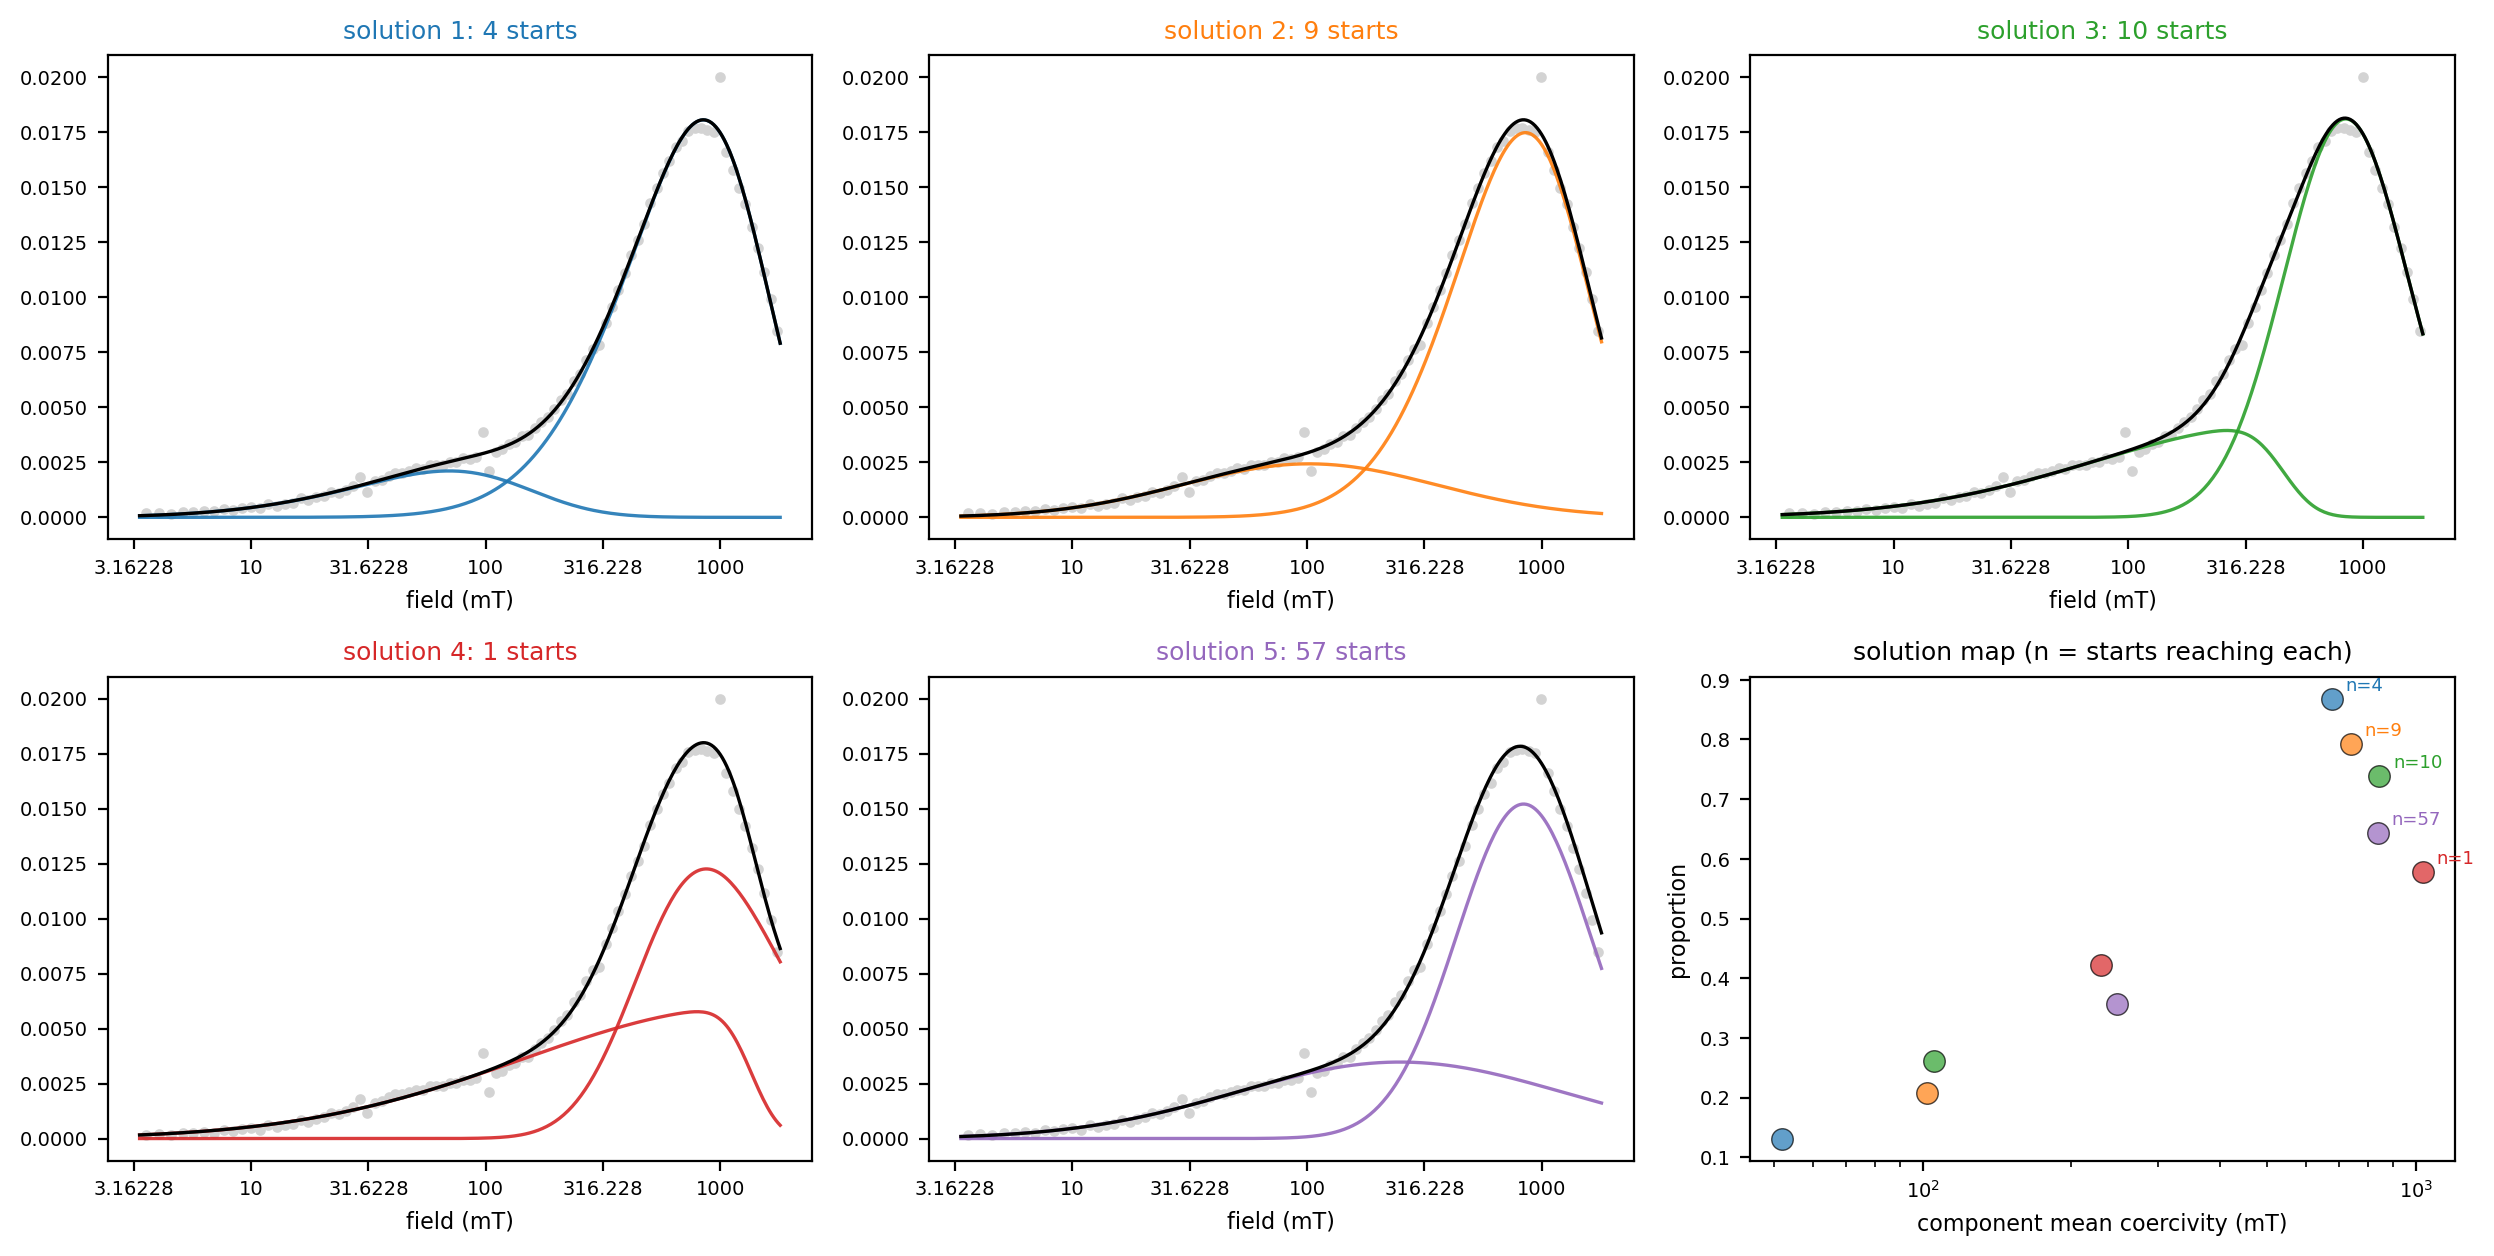

In [9]:
fig, axes = rmag.plot_unmixing_multistart(multistart, max_solutions=5,
                                           space='spectrum')
plt.show()

Each small-multiple panel is a different, self-consistent way to split the same spectrum into two components: a broad low-coercivity component plus a narrow high-coercivity one, but with the boundary between them drawn in materially different places (a ~55 mT + ~680 mT split, a ~110 mT + ~830 mT split, a ~240 mT + ~830 mT split, and so on). Every one of these reproduces the measured spectrum well. They are not bad fits; they are alternative fits.

The solution map on the last panel is the key diagnostic. It shows the distinct solutions as a chain of clusters strung along a coercivity-proportion ridge: as a component is allowed to move to higher coercivity, its fitted proportion rises to compensate, tracing out the family of decompositions the data permit. All five solutions fit the spectrum essentially perfectly (R² ≈ 1.00 for every one): they are visually indistinguishable, and no realistic measurement-error model could tell them apart, so none should be singled out as the answer. (`unmixing_multistart` also reports an Akaike weight per solution. On data this clean it collapses onto the single lowest-RSS split and should not be read as discrimination; it becomes informative only when the measurement noise is large enough to spread support across solutions.)

Two lessons follow:

- **The most frequently found solution is not necessarily the best-fitting one.** In this run the solution reached by the most random starts (the largest `n_hits`, here the ~248 + ~837 mT split, found by 57 of 80 starts) is not the lowest-RSS one (the ~52 + ~675 mT split, found by only 4). A broad attracting basin is not the same as a good fit, and reporting "the answer the optimizer converged to" conflates the two.
- **Some of the uncertainty is between solutions, not within one.** The bootstrap and the posterior (below) describe the continuous spread around a single decomposition, a band about one solution. Multi-start exposes a separate source of uncertainty: several distinct decompositions sitting in different places, which no band around one fit can represent.

When the solutions are spread across several distinct clusters like this, no single decomposition should be over-interpreted. Two responses are available: report only quantities that are robust across the solutions (for example, the total remanence above and below a coercivity threshold, which `rmag.aggregate_by_class` computes, demonstrated near the end of this notebook), or break the degeneracy with independent mineralogical information supplied as the Bayesian priors below.

## Layer 3: the Bayesian posterior

Nested sampling (Skilling, 2006, run here with `dynesty`; Speagle, 2020) searches the whole parameter space at once and returns the posterior: the set of decompositions consistent with the data and the priors, each with its probability. It is the most complete of the three uncertainty pictures. The bootstrap captures sensitivity to noise and multi-start reveals separate solutions; the posterior captures both at the same time, and it folds in prior knowledge directly. As a by-product it computes the evidence ($\log z$), the number used below to choose how many components to fit.

### Two data spaces: measurement vs. spectrum

The same skew-normal component model can be fit in either of two data spaces, chosen with the `space` argument of the Bayesian method:

- **`space='curve'`**: fit the measured cumulative curve $M(B)$ with cumulative components plus a constant offset. An independent Gaussian noise model is defensible here, since the raw measurements are independent, and no numerical differentiation is needed. This is the conservative choice.
- **`space='spectrum'`** (used in the application above): fit the finite-difference coercivity spectrum $\mathrm{d}M/\mathrm{d}\log_{10}B$ directly. Fitting the derivative reproduces the shape of each coercivity peak, whereas a cumulative-curve fit is only weakly sensitive to the peak and tends to under-represent it, and it lets the component skewness be set by the peak shape rather than left unconstrained. The trade-off is that differencing correlates adjacent points, so the i.i.d. (independent and identically distributed) Gaussian likelihood is an approximation, the same one the least-squares and MAX UnMix spectrum fits make. Credible intervals from this space are best cross-checked against a `space='curve'` fit.

Because the component parameterization (area, location, dispersion, skew) is identical in both spaces, their results are directly comparable, and agreement between them is a useful robustness check. Component locations are kept in a fixed coercivity order (sampled as order statistics) so the component labels stay meaningful, and the noise standard deviation is itself a free parameter.

### The unconstrained posterior

We first use weakly informative default priors (component mean coercivities anywhere across the measured field range, dispersions log-uniform between 0.02 and 1 decade, skew free) to see what the data alone determine, before adding any mineralogical knowledge.

log-evidence = 201.6 +/- 0.39
posterior noise estimate = 0.0003663


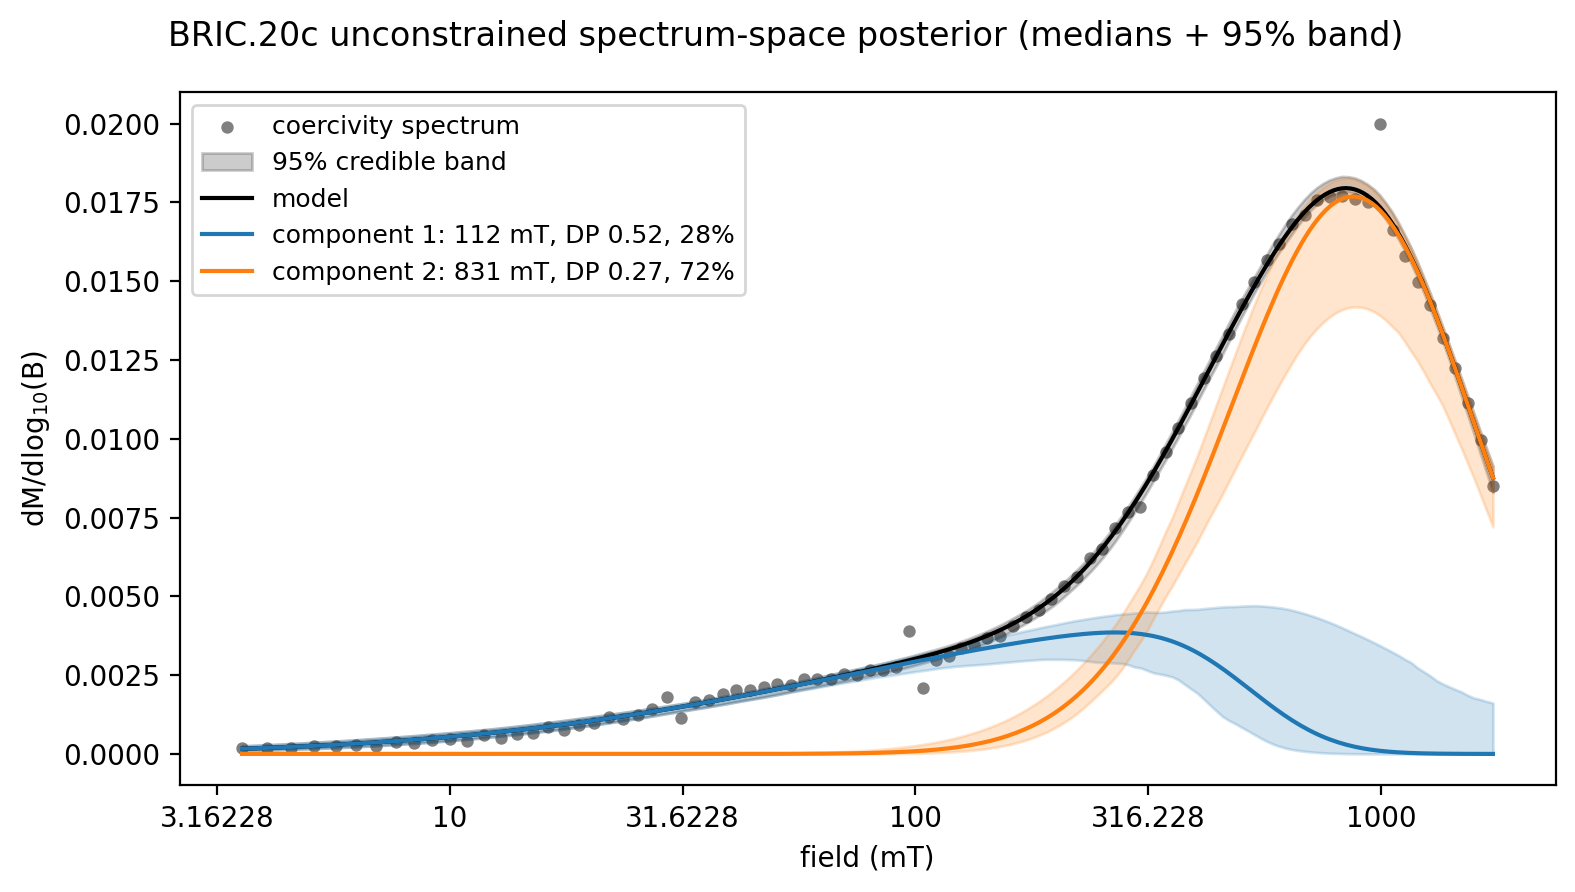

In [10]:
posterior = rmag.unmix_coercivity(x, M, method='bayes', space='spectrum',
                                  n_components=2, vary_skew=True,
                                  random_seed=1)
print(f"log-evidence = {posterior['bayes']['logz']:.1f} "
      f"+/- {posterior['bayes']['logzerr']:.2f}")
print(f"posterior noise estimate = {posterior['bayes']['noise']:.4g}")
fig, axes = rmag.plot_coercivity_unmixing(
    posterior,
    title='BRIC.20c unconstrained spectrum-space posterior (medians + 95% band)')
plt.show()

### The posterior distribution quantifies the uncertainty

Because the posterior is a full distribution over decompositions, the same three visualizations now describe the complete uncertainty rather than just noise repeatability. The marginal posteriors give credible intervals directly:

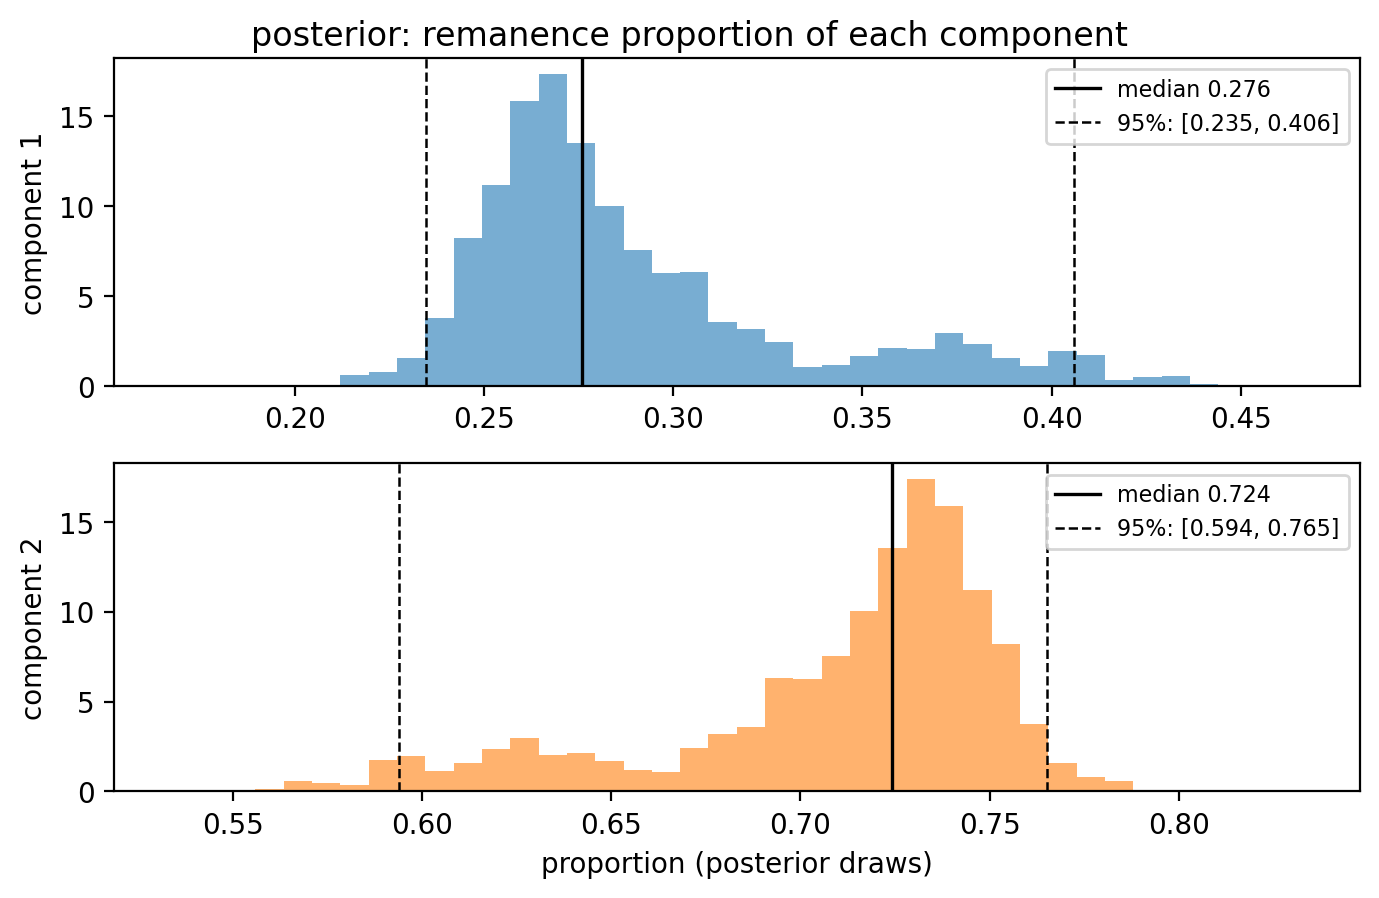

In [11]:
fig, axes = rmag.plot_unmixing_posterior(posterior, quantity='proportion')
fig.suptitle('posterior: remanence proportion of each component', y=1.01)
plt.show()

The posterior ensemble plot shows the range of decompositions the data and priors permit. Compared with the bootstrap ensemble above, the posterior spread of the broad component is wider still, because it accounts for the parameter trade-offs and the weak prior rather than being anchored to one optimizer solution:

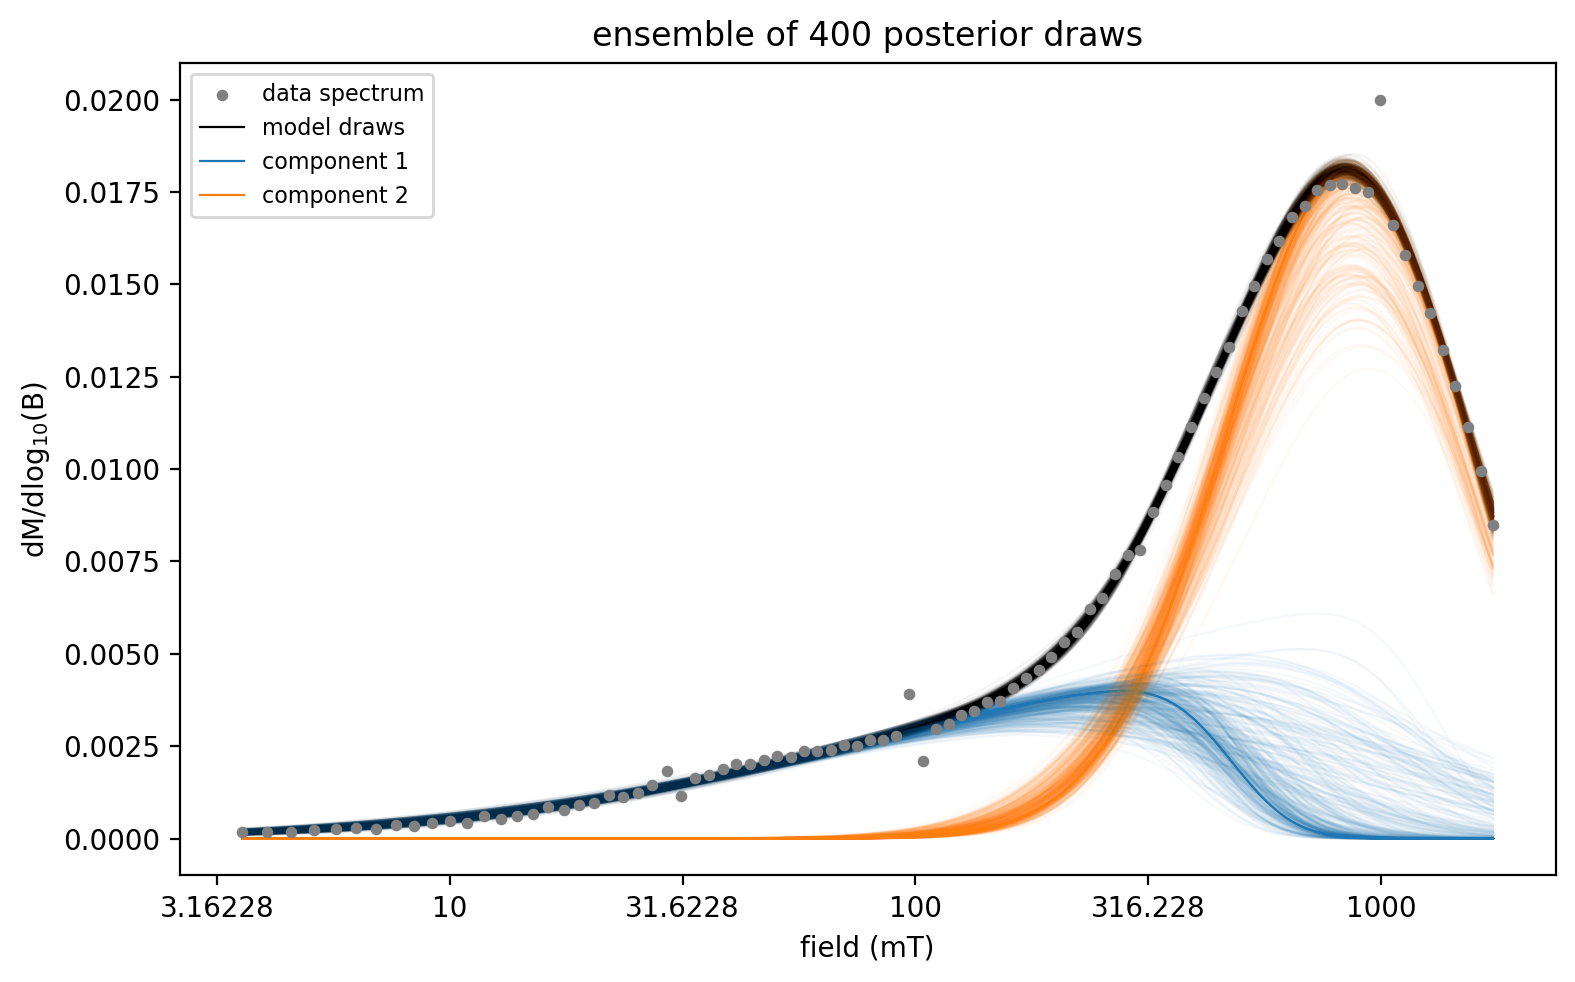

In [12]:
fig, ax = rmag.plot_unmixing_ensemble(posterior, space='spectrum',
                                      n_draws=400, random_seed=1)
plt.show()

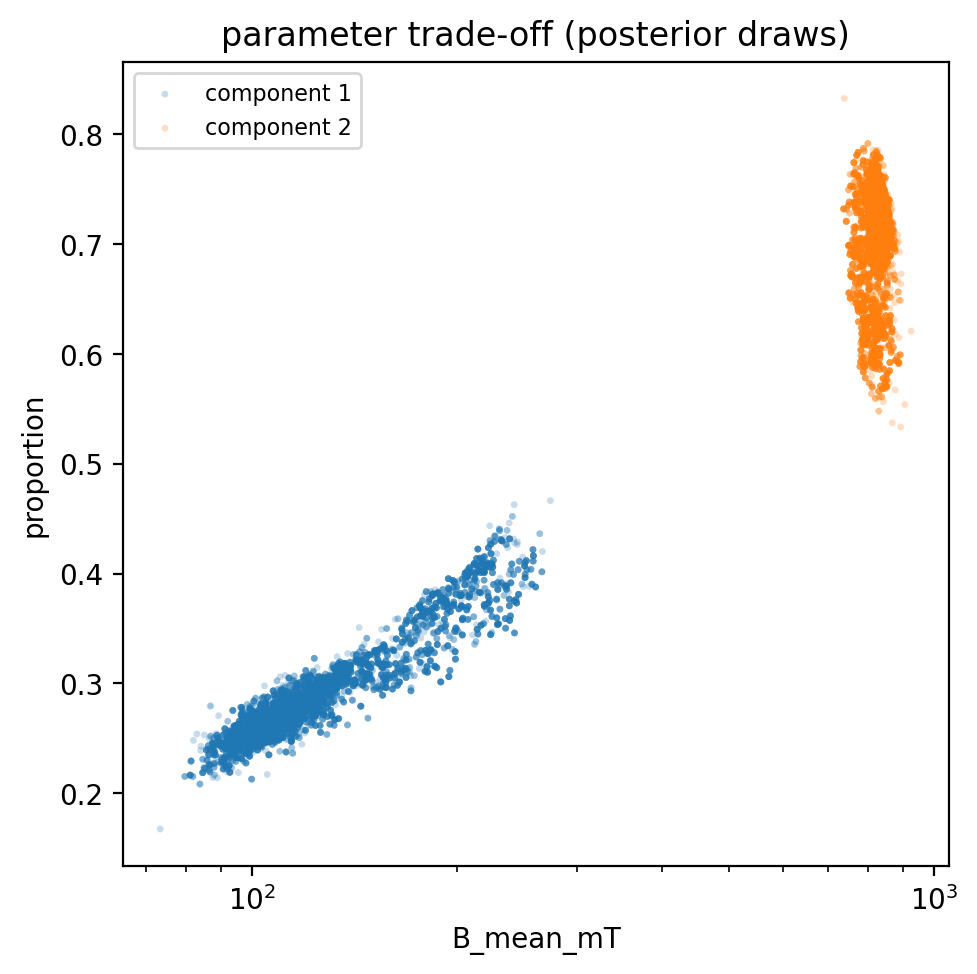

In [13]:
fig, ax = rmag.plot_unmixing_tradeoff(posterior, x='B_mean_mT',
                                      y='proportion')
plt.show()

### Choosing the number of components with the evidence

Nested sampling returns the Bayesian evidence (marginal likelihood, `logz`), a principled criterion for model selection: it rewards fit quality but automatically penalizes components the data cannot constrain, integrating over the whole prior volume rather than evaluating at a single best fit. Comparing evidences across component counts selects the model the data actually support.

In [14]:
evidences = {}
for n in (1, 2, 3):
    fit = rmag.unmix_coercivity(x, M, method='bayes', n_components=n,
                                vary_skew=False, random_seed=1)
    evidences[n] = fit['bayes']['logz']
evidence_table = pd.DataFrame({
    'n_components': list(evidences),
    'log_evidence': list(evidences.values()),
})
evidence_table['delta_log_evidence'] = (
    evidence_table['log_evidence'] - evidence_table['log_evidence'].max())
evidence_table.round(2)

,n_components,log_evidence,delta_log_evidence
0,1,175.97,-279.56
1,2,428.13,-27.39
2,3,455.52,0.00


A difference in log-evidence greater than ~5 is decisive (Jeffreys' scale). The evidence jumps enormously from one to two components, confirming that a single component is badly inadequate. It then continues to rise for three components, so taken literally the statistics prefer three.

This is an important and general caution. With high-resolution, low-noise curves like this one, the evidence (and information criteria such as AIC/BIC) will often keep rewarding additional components, because a real coercivity distribution is never exactly log-Gaussian and extra components mop up small systematic misfits. The statistics tell you how many components the data can distinguish, not how many minerals are present. Here the two red-bed hematite populations are well established mineralogically (Swanson-Hysell et al., 2019), and a third statistically supported component near one of them is not a third mineral.

### A parsimony rule: prefer the simplest adequate model

Because criterion-minimization keeps adding components, model selection needs an explicit preference for simplicity: choose the simplest model that is already adequate, rather than the one that optimizes a score (the parsimony principle of Egli, 2003, and Heslop, 2015). `rmag.select_n_components` implements this. Its default rule retains an added component only if it reduces the residual by at least a set fraction (default 2%) of the baseline single-component misfit. The second component removes the overwhelming majority of the misfit and is kept; a third removes a fraction of a percent and is rejected, no matter how low the noise is.

In [15]:
n_selected, selection_table, _fits = rmag.select_n_components(
    x, M, method='curve', max_components=4, verbose=True)
selection_table[['n_components', 'r_squared', 'rss_improvement_fraction',
                 'reduced_chi2', 'selected']].round(4)

selected 2 component(s) by 'parsimony' criterion (noise ~ 1.56e-06)


,n_components,r_squared,rss_improvement_fraction,reduced_chi2,selected
0,1,0.9972,NaN,23374.7821,False
1,2,1.0000,0.9985,35.6218,True
2,3,1.0000,0.0000,37.0086,False
3,4,1.0000,0.0010,12.3023,False


The parsimony rule selects two components even though the evidence would keep rewarding more. The `rss_improvement_fraction` column shows why: the second component explains almost all of the baseline misfit and the third almost none. This gives an objective, reproducible stopping rule that resists the low-noise over-fitting trap, while the `reduced_chi2` and evidence columns remain available for inspection. The `criterion='chi2'` option instead selects the simplest model that fits to within the estimated measurement noise. Its noise estimator is spacing-aware, so it is not fooled by the coarse, log-spaced field grid, but chi-square (like the evidence) still tends to over-select on low-noise data once the noise is no longer over-estimated, so `parsimony` remains the more robust default. In all cases the final decision should be sanity-checked against the expected mineralogy, which the mineral-prior approach below builds in directly.

## Constraining the decomposition with mineralogical priors

The most effective antidote to non-uniqueness is independent knowledge of the likely mineralogy (Heslop, 2015). `rmag.COERCIVITY_COMPONENT_LIBRARY` collects characteristic coercivity ranges for common remanence carriers: magnetite in its igneous, detrital, eolian, pedogenic, and biogenic (soft and hard) forms (Egli, 2004a,b; Roberts, 2025), oxidized maghemite, the ferrimagnetic iron sulphides greigite and pyrrhotite, and the antiferromagnetic pigmentary and detrital hematite (Roberts, 2025; Özdemir & Dunlop, 2014). `rmag.mineral_priors` turns a list of component names into priors for the Bayesian method. Goethite is deliberately omitted: because it does not saturate even in ~57 T fields, an ordinary coercivity spectrum captures only an ambiguous low-coercivity tail that overlaps hematite and cannot quantify it, so a high-coercivity component that might be goethite is better confirmed by independent (thermal or low-temperature) evidence than fit as a goethite prior. Several of these minerals overlap in coercivity (greigite and pyrrhotite overlap biogenic-hard magnetite; pyrrhotite overlaps pigmentary hematite), so the priors constrain a coercivity window and should be combined with independent mineral identification (thermal, low-temperature, or FORC diagnostics) rather than treated as identifications on their own.

The figure and table below are an atlas of the library: each mineral's representative coercivity distribution (its shape set by the central dispersion and skew) over a shared field axis, with the bar marking its mean-coercivity window. Reading them together shows why a coercivity prior is a window, not an identification: the magnetite family, maghemite, and greigite overlap at low coercivity, and the hematite components overlap each other at high coercivity.

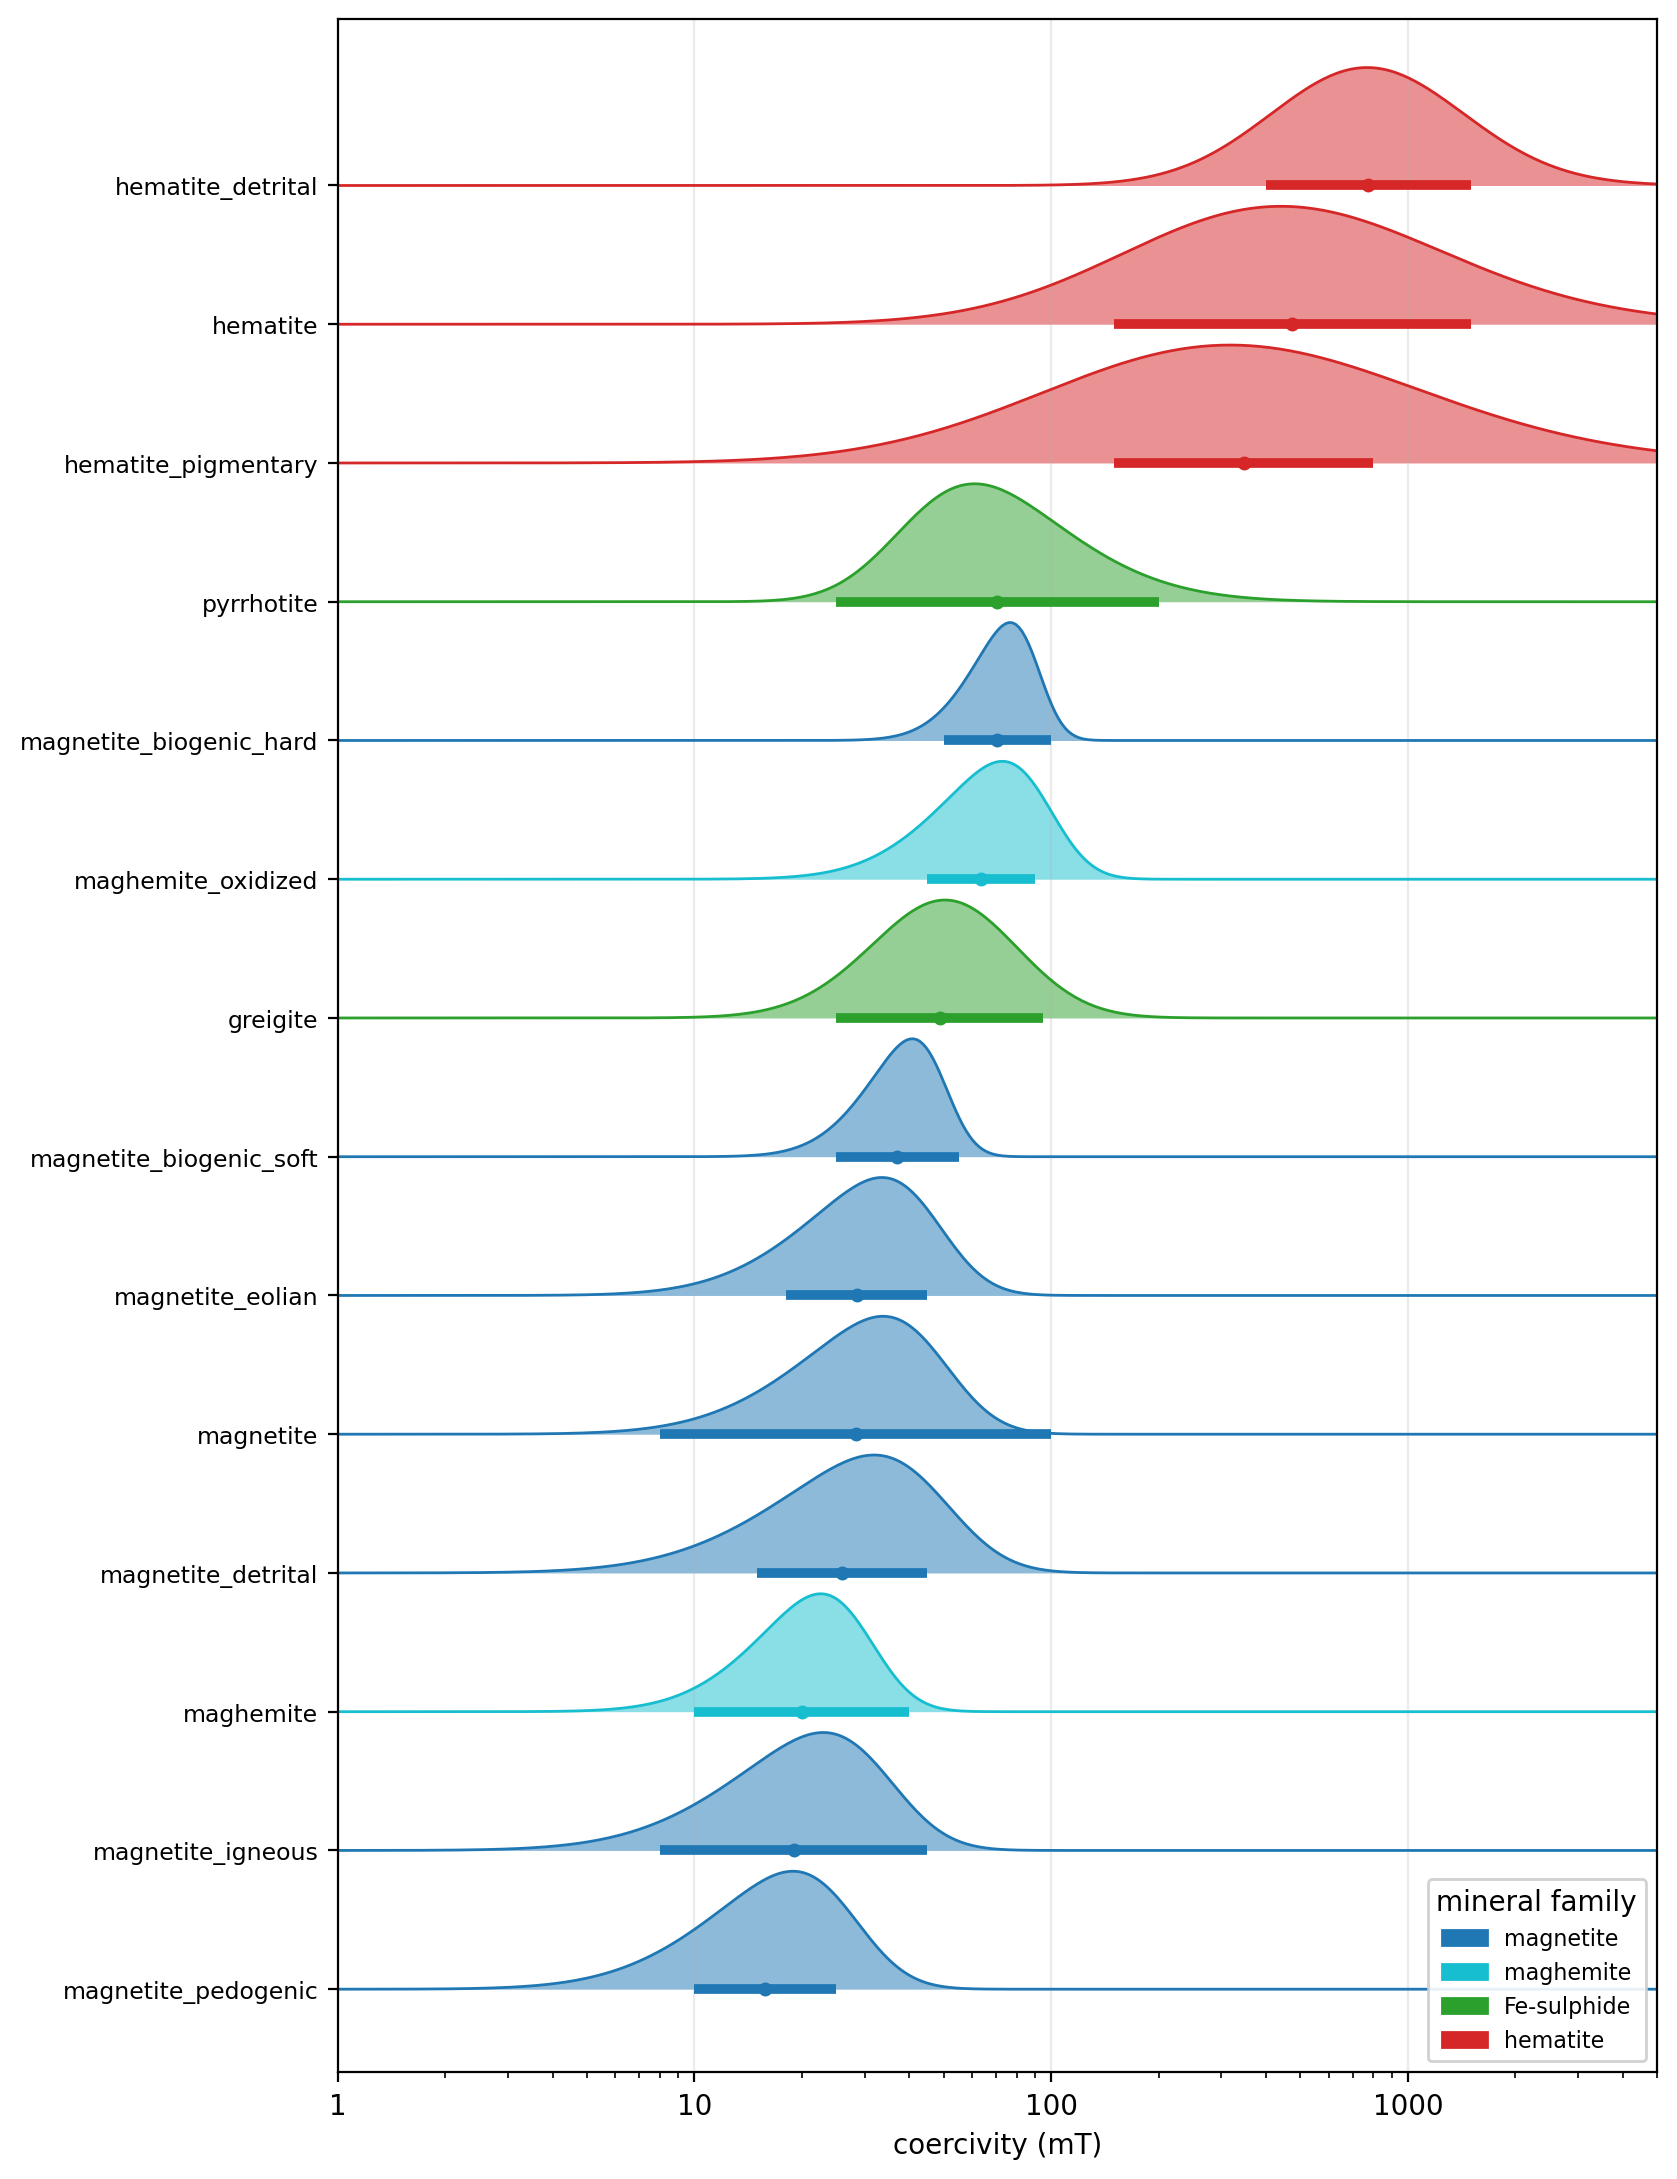

,component,family,mean coercivity (mT),dp (log10),skew (alpha),asymmetry
0,magnetite_pedogenic,magnetite,10-25,0.25-0.4,-5-0,left (low-field tail)
1,magnetite_igneous,magnetite,8-45,0.2-0.5,-5-0,left (low-field tail)
2,maghemite,maghemite,10-40,0.15-0.35,-5-0.5,left (low-field tail)
3,magnetite_detrital,magnetite,15-45,0.3-0.45,-5-0,left (low-field tail)
4,magnetite,magnetite,8-100,0.15-0.5,-5-0,left (low-field tail)
5,magnetite_eolian,magnetite,18-45,0.2-0.4,-5-0,left (low-field tail)
6,magnetite_biogenic_soft,magnetite,25-55,0.1-0.25,-5-0,left (low-field tail)
7,greigite,Fe-sulphide,25-95,0.15-0.35,-3-1,left (low-field tail)
8,maghemite_oxidized,maghemite,45-90,0.15-0.35,-5-0,left (low-field tail)
9,magnetite_biogenic_hard,magnetite,50-100,0.08-0.22,-5-0,left (low-field tail)


In [16]:
# an atlas of the library: representative coercivity distribution and
# mean-coercivity window for each mineral component, grouped by family
fig, ax = rmag.plot_coercivity_prior_library()
plt.show()
rmag.coercivity_prior_table()[['component', 'family', 'mean coercivity (mT)',
                               'dp (log10)', 'skew (alpha)', 'asymmetry']]

**How a library window becomes a prior.** For each named component, `mineral_priors` returns three windows, on the mean coercivity `B_median_mT`, the dispersion `dp`, and the skew, which `unmix_coercivity_bayes` uses as follows:

- **Mean coercivity, not location.** The window constrains the component's mean coercivity $10^{\,B\_mean}$ directly: the mean is sampled uniformly across the window and the skew-normal location parameter is derived from the sampled dispersion and skew. This matters because for a skewed component the bare location parameter is not a physical coercivity, so a window applied to the location would drift away from the tabulated median under skew. Constraining the mean keeps the window meaning what it says ("this mineral's mean coercivity lies in this range") whatever the fitted skew, and it is the quantity you compare to a class boundary. A side benefit is that a component can carry free, data-driven skew and still be held in its coercivity window.
- **Physically signed skew.** The skew windows carry the sign the rock-magnetic literature supports: magnetite and maghemite are left-skewed on the log-field axis (a heavier low-field tail; Roberts, 2025, p. 117; Egli, 2003), goethite and pyrrhotite are right-skewed (a hard, non-saturating high-field tail), greigite is near-symmetric, and hematite is variable. The magnitudes are the Azzalini shape parameter $\alpha$ (not the moment skewness), sized so that $|\alpha|\sim2$–$5$ gives a visibly skewed component. They are deliberately broad, since only the sign is well constrained by the literature.
- **Sources.** Coercivity and dispersion ranges for the magnetite family and maghemite come from the component analyses of Egli (2003; 2004a), cross-checked against the grain-size systematics in Roberts (2025); hematite is anchored to the grain-size–coercivity relation of Özdemir & Dunlop (2014) ($H_c\propto d^{-0.61}$ over the ~100s nm to 100s µm range that carries a resolvable remanence); sulphides and goethite are from Roberts (2025). Roberts (2025) reports no numeric dispersion or skew, so those are taken from the Egli/Kruiver lineage and the literature signs, documented per entry in the library `source` field.

These ranges are deliberately broad and are soft constraints, not identifications. Important caveats, drawn from Roberts (2025):

- the magnetite values derive from AF-demagnetization median destructive fields, which are comparable to but not identical with IRM/backfield median fields;
- hematite coercivity is grain-size controlled ($H_c\propto d^{-0.61}$; Özdemir & Dunlop, 2014), so finer hematite is harder; aluminium substitution raises it up to ~7–13 mol% Al and then lowers it, though that trend is strongly confounded by covarying grain size (Roberts, 2025);
- goethite is deliberately excluded from the library: it does not magnetically saturate even in 57 T fields, so a backfield or IRM coercivity spectrum captures only an ambiguous low-coercivity tail that overlaps hematite and cannot quantify it. A high-coercivity component that might be goethite should be confirmed with independent (thermal or low-temperature) evidence rather than fit as a goethite prior. (Pass `field_max_mT` in general so no prior places support beyond the measured field.)

Interpreting the two BRIC.20c components as pigmentary and detrital hematite, the priors resolve the non-uniqueness seen in the multi-start analysis by restricting each component to its mineral's coercivity window:

components (low to high coercivity): ['hematite_pigmentary', 'hematite_detrital']


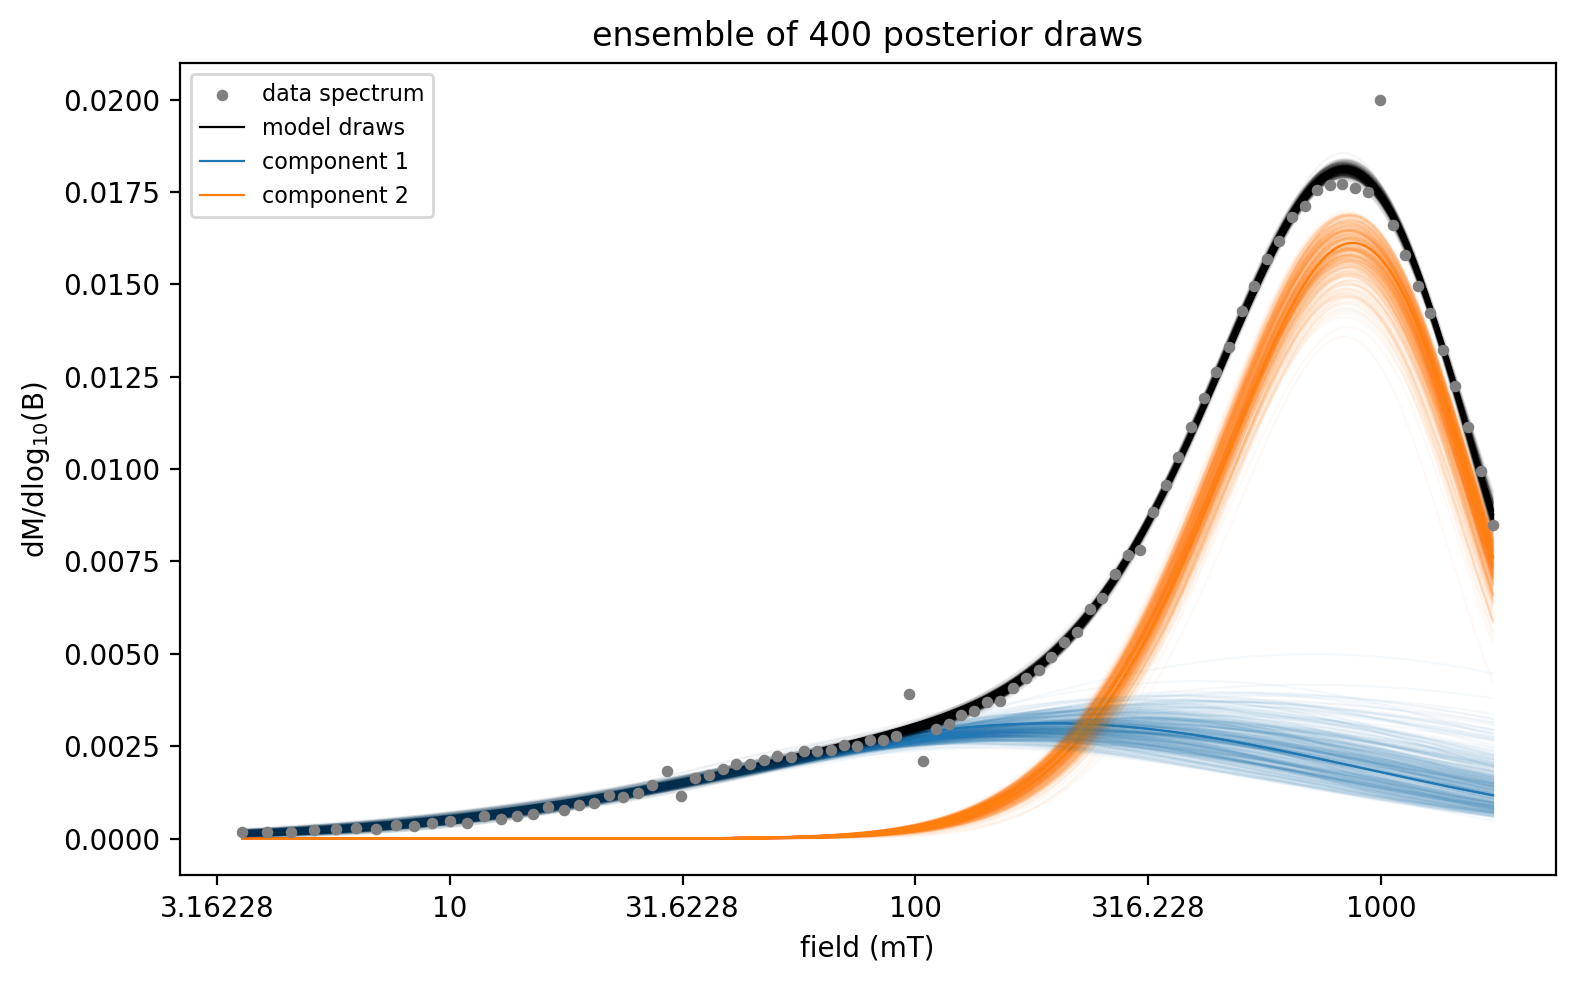

,B_mean_mT_p2_5,B_mean_mT_p50,B_mean_mT_p97_5,proportion_p2_5,proportion_p50,proportion_p97_5
component,,,,,,
1,152.841,203.704,448.673,0.259,0.32,0.452
2,738.298,757.301,792.578,0.548,0.68,0.741


In [17]:
field_max_mT = 10 ** x.max()
priors = rmag.mineral_priors(['hematite_pigmentary', 'hematite_detrital'],
                             field_max_mT=field_max_mT)
print('components (low to high coercivity):', priors['components'])
posterior_priors = rmag.unmix_coercivity(x, M, method='bayes',
                                         space='spectrum', priors=priors,
                                         vary_skew=True, random_seed=1)
fig, ax = rmag.plot_unmixing_ensemble(posterior_priors, space='spectrum',
                                      n_draws=400, random_seed=1)
plt.show()
posterior_priors['bayes']['param_summary'][[
    'B_mean_mT_p2_5', 'B_mean_mT_p50', 'B_mean_mT_p97_5',
    'proportion_p2_5', 'proportion_p50', 'proportion_p97_5']].round(3)

With mineralogical priors the ensemble is tighter than the weakly informative posterior: the pigmentary and detrital hematite components are each held within their coercivity windows, and the remaining spread reflects what the data still leave undetermined inside those windows. This workflow is the one to reach for when the mineralogy is known well enough to bracket each component.

### Tuning the priors to your dataset

The library windows are broad starting points, not final answers. A real sample often carries a mineral whose coercivity sits outside the tabulated range: a harder, finer-grained detrital magnetite, or a hematite whose low-coercivity shoulder begins below the detrital-hematite window. Rather than hand-building a priors dictionary, adapt the library windows in place. The recommended workflow is to fit unconstrained first, see where the components land, and then set the windows to bracket them:

- `widen` broadens every window about its center (use when the library range is too tight for your grains);
- `tighten` narrows every window (use when independent constraints justify it; the two compose, for a net width factor `widen / tighten`);
- `overrides` replaces a specific mineral's window outright, leaving every other mineral anchored to the library.

For example, a suite of red-bed backfield curves may carry a magnetite that is harder than typical detrital magnetite and a hematite whose shoulder starts well below the detrital-hematite window. Both windows are set explicitly with `overrides` while the call still reads as "magnetite plus hematite":

In [18]:
# broaden every window by 50%
wide = rmag.mineral_priors(['magnetite_detrital', 'hematite'], widen=1.5)

# or replace only the windows your samples require, keeping the rest from the library
tuned = rmag.mineral_priors(
    ['magnetite_detrital', 'hematite'],
    overrides={
        'magnetite_detrital': {'B_median_mT': (20.0, 160.0)},
        'hematite': {'B_median_mT': (300.0, 2000.0)},
    })
for name, (lo, hi) in zip(tuned['components'], tuned['mean']):
    print(f'{name:20s} mean-coercivity window: {10**lo:7.1f} - {10**hi:7.1f} mT')

magnetite_detrital   mean-coercivity window:    20.0 -   160.0 mT
hematite             mean-coercivity window:   300.0 -  2000.0 mT


### Credible intervals are conditional on the model and the priors

The percentiles reported above (2.5 / 50 / 97.5) are credible intervals given the fitted model and the priors, not model-independent error bars. Two dependencies are worth stating plainly:

- **They depend on the number of components.** An interval from a two-component fit describes the uncertainty of that decomposition; a three-component fit of the same data partitions the remanence differently and yields different intervals. This is why quantities that are robust to component count, for example the summed remanence above and below a coercivity boundary (`rmag.aggregate_by_class`), are safer to interpret and to compare across samples than any single component's parameters.
- **They depend on the prior windows.** Tightening a window narrows the interval; widening it (or dropping to weakly informative priors) widens it. A narrow credible interval therefore reflects a narrow prior as much as it reflects informative data, and where two minerals overlap in coercivity the split between them is constrained largely by the priors. Report the windows you used alongside the intervals, and where the science depends on it, check how much the interval moves when the windows are widened.

In short, a credible interval answers "how well is this quantity determined, assuming this model and these priors?"

### Count-robust reporting with `aggregate_by_class`

`rmag.aggregate_by_class` implements the count-robust reporting recommended above. It sums each fitted component's remanence proportion (and contribution) into classes defined by coercivity cut points, so the class totals do not depend on how the optimizer subdivided a population, provided the cut points separate the populations. Below, the reference least-squares fit and the prior-constrained posterior, two quite different models of the same curve, are aggregated at a 500 mT boundary and return similar pigmentary/detrital splits. For populations that partly overlap a boundary, as these two hematites do, the class split inherits that ambiguity, which the credible intervals above quantify.

In [19]:
class_input = []
for label, fit in [('least-squares reference', reference),
                   ('Bayesian with priors', posterior_priors)]:
    components = fit['params'].reset_index()
    components['model'] = label
    class_input.append(components)
class_fractions = rmag.aggregate_by_class(
    pd.concat(class_input, ignore_index=True),
    boundaries_mT=500, class_names=['pigmentary', 'detrital'],
    group_column='model')
class_fractions.round(3)

,model,pigmentary_fraction,pigmentary_remanence,detrital_fraction,detrital_remanence
0,Bayesian with priors,0.321,0.003,0.679,0.006
1,least-squares reference,0.357,0.003,0.643,0.005


## Extending the framework with custom methods

All unmixing methods live in a registry (`rmag.UNMIXING_METHODS`) and share one call signature and result structure, so alternative strategies can be registered with `rmag.register_unmixing_method` and then used everywhere, including in `unmix_backfield_experiments` batch runs and with all the uncertainty tools above. The example below registers a method that fits the measured curve directly and then estimates its uncertainties by MAX UnMix-style case resampling (each replicate refits 95% of the points with 2% added measurement noise).

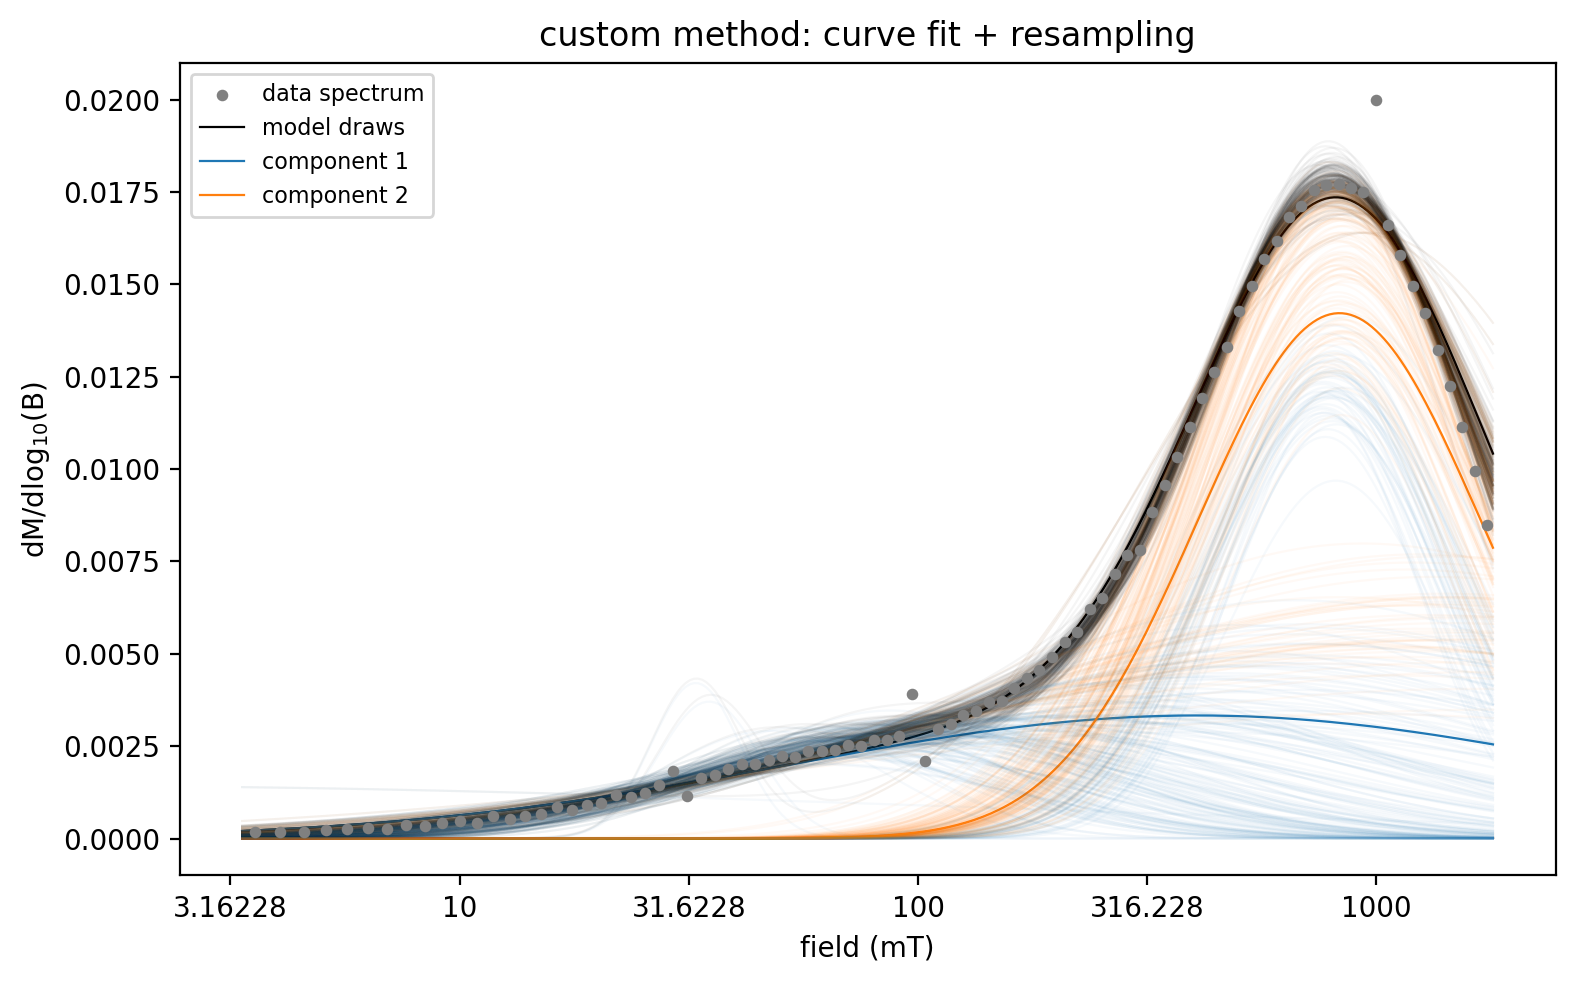

,B_mean_mT,sd_log,proportion
component,,,
1,248.333,0.694,0.357
2,836.779,0.285,0.643


In [20]:
def curve_with_resampling(x, magnetization, n_components=None,
                          initial_parameters=None, curve_type='backfield',
                          vary_skew=True, n_boot=200, random_seed=None,
                          **kwargs):
    """Measurement-space fit with MAX UnMix-style resampling uncertainties."""
    result = rmag.unmix_backfield_curve(x, magnetization,
                                        n_components=n_components,
                                        initial_parameters=initial_parameters,
                                        curve_type=curve_type,
                                        vary_skew=vary_skew, **kwargs)
    return rmag.unmixing_bootstrap(result, n_boot=n_boot, resample='cases',
                                   proportion=0.95, noise_level=0.02,
                                   random_seed=random_seed)

rmag.register_unmixing_method('curve_maxunmix', curve_with_resampling)

custom = rmag.unmix_coercivity(x, M, method='curve_maxunmix', n_components=2,
                               vary_skew=False, random_seed=1)
fig, ax = rmag.plot_unmixing_ensemble(custom, space='spectrum', n_draws=200,
                                      random_seed=1,
                                      title='custom method: curve fit + resampling')
plt.show()
custom['params'][['B_mean_mT', 'sd_log', 'proportion']].round(3)

Because the custom method returns the standard result structure (here including a `bootstrap` entry), every uncertainty visualization works on it unchanged. You can drop in a new basis function, a different likelihood, or an alternative sampler and immediately reuse the entire uncertainty and batch-processing infrastructure.

## Summary

- A high $R^2$ does not mean a decomposition is well constrained. Coercivity unmixing is ill-posed, and its uncertainty must be assessed explicitly.
- Choose the number of components with a parsimony rule (`rmag.select_n_components`), not by minimizing AIC/BIC or maximizing the evidence. On low-noise data those keep favoring more components indefinitely.
- Use the bootstrap (`unmixing_bootstrap`) for noise repeatability within a solution, multi-start (`unmixing_multistart`) to reveal alternative solutions, and the Bayesian posterior (`method='bayes'`) for the complete uncertainty representation.
- Fit either the measured curve (`space='curve'`) or the coercivity spectrum directly (`space='spectrum'`). The spectrum fit reproduces the coercivity peak and lets the skew be data-driven, at the cost of an approximate noise model, so treating the two spaces as a cross-check is good practice.
- Visualize uncertainty with `plot_unmixing_posterior` (marginal credible intervals), `plot_unmixing_ensemble` (the range of decompositions in spectrum space), and `plot_unmixing_tradeoff` (parameter correlations). All work identically on bootstrap and posterior results.
- Constrain ill-posed decompositions with mineralogical priors (`rmag.mineral_priors`), whose windows constrain each component's mean coercivity directly and carry a physically signed skew. Adapt them to your samples with `widen`, `tighten`, and `overrides`, and report the windows alongside the residual posterior uncertainty rather than a single best fit.
- Credible intervals are conditional on the component count and the prior windows. Prefer count-robust quantities (`rmag.aggregate_by_class`, e.g. remanence above/below a coercivity boundary) when comparing across samples.

## References

Egli, R. (2003). Analysis of the field dependence of remanent magnetization curves. *Journal of Geophysical Research*, 108(B2), 2081. https://doi.org/10.1029/2002JB002023

Egli, R. (2004a). Characterization of individual rock magnetic components by analysis of remanence curves, 1. Unmixing natural sediments. *Studia Geophysica et Geodaetica*, 48, 391–446.

Egli, R. (2004b). Characterization of individual rock magnetic components by analysis of remanence curves, 2. Fundamental properties of coercivity distributions. *Physics and Chemistry of the Earth*, 29, 851–867.

Kruiver, P. P., Dekkers, M. J., & Heslop, D. (2001). Quantification of magnetic coercivity components by the analysis of acquisition curves of isothermal remanent magnetisation. *Earth and Planetary Science Letters*, 189, 269–276. https://doi.org/10.1016/S0012-821X(01)00367-3

Robertson, D. J., & France, D. E. (1994). Discrimination of remanence-carrying minerals in mixtures, using isothermal remanent magnetisation acquisition curves. *Physics of the Earth and Planetary Interiors*, 82, 223–234. https://doi.org/10.1016/0031-9201(94)90074-4

Heslop, D. (2015). Numerical strategies for magnetic mineral unmixing. *Earth-Science Reviews*, 150, 256–284. https://doi.org/10.1016/j.earscirev.2015.07.007

Maxbauer, D. P., Feinberg, J. M., & Fox, D. L. (2016). MAX UnMix: A web application for unmixing magnetic coercivity distributions. *Computers & Geosciences*, 95, 140–145. https://doi.org/10.1016/j.cageo.2016.07.009

Özdemir, Ö., & Dunlop, D. J. (2014). Hysteresis and coercivity of hematite. *Journal of Geophysical Research: Solid Earth*, 119, 2582–2594. https://doi.org/10.1002/2013JB010739

Roberts, A. P. (2025). *Mineral Magnetism*. Cambridge University Press. https://doi.org/10.1017/9781108935630

Skilling, J. (2006). Nested sampling for general Bayesian computation. *Bayesian Analysis*, 1, 833–859. https://doi.org/10.1214/06-BA127

Speagle, J. S. (2020). dynesty: a dynamic nested sampling package for estimating Bayesian posteriors and evidences. *Monthly Notices of the Royal Astronomical Society*, 493, 3132–3158. https://doi.org/10.1093/mnras/staa278

Swanson-Hysell, N. L., Fairchild, L. M., & Slotznick, S. P. (2019). Primary and secondary red bed magnetization constrained by fluvial intraclasts. *Journal of Geophysical Research: Solid Earth*, 124. https://doi.org/10.1029/2018JB017067